In [2]:
!pip install librosa

   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.7 MB ? eta -:--:--
   ------- -------------------------------- 0.5/2.7 MB 1.7 MB/s eta 0:00:02
   ----------- ---------------------------- 0.8/2.7 MB 1.6 MB/s eta 0:00:02
   ----------- ---------------------------- 0.8/2.7 MB 1.6 MB/s eta 0:00:02
   --------------- ------------------------ 1.0/2.7 MB 1.1 MB/s eta 0:00:02
   ------------------- -------------------- 1.3/2.7 MB 1.0 MB/s eta 0:00:02
   ----------------------- ---------------- 1.6/2.7 MB 1.1 MB/s eta 0:00:02
   --------------------------- ------------ 1.8/2.7 MB 1.1 MB/s eta 0:00:01
   --------------------------- ------------ 1.8/2.7 MB 1.1 MB/s eta 0:00:01
   ------------------------------- -------- 2.1/2.7 MB 1.1 MB/s eta 0:00:01
   ----------------------------------- ---- 2.4/2.7 MB 1.1 MB/s eta 0:00:01
   ----------------------------------- ---- 2.4/2.7 MB 1.1 MB/s eta 0:00:01
   -----------------------

In [3]:
import pandas as pd
import librosa
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.naive_bayes import GaussianNB 
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn import svm
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb

from sklearn.ensemble import AdaBoostClassifier
from sklearn.mixture import GaussianMixture
#import tensorflow as tf

# Import the SGD optimizer
#optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)


#import lightgbm as lgb

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from imblearn.over_sampling import RandomOverSampler

from imblearn.over_sampling import SMOTE


from sklearn.preprocessing import LabelEncoder

# initialize the encoder
le = LabelEncoder()


import librosa
import numpy as np
import pandas as pd
import os
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

from sklearn.decomposition import PCA
from sklearn.ensemble import AdaBoostClassifier




In [3]:
n_mfcc = 40
n_fft = 512  # setting the FFT size to 1024
hop_length = 10*16 # 25ms*16khz samples has been taken
win_length = 30*16 #25ms*16khz samples has been taken for window length
window = 'hann' #hann window used
n_chroma=12
n_mels=128
n_bands=7 #we are extracting the 7 features out of the spectral contrast
fmin=100
bins_per_ocatve=12

In [6]:
train_path  = 'NewData/'
train_meta = pd.read_csv('NewMETA.csv')
train_meta.head()

C:\Users\vaibh\AppData\Local\Temp\ipykernel_35072\961543318.py:2: DtypeWarning: Columns (0,1,4,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  train_meta = pd.read_csv('NewMETA.csv')


,Filename,File ID,Duration in ms,Class ID,Classname,augmentation id,Augmentation type,source,Unnamed: 8,Unnamed: 9,...,Unnamed: 184,Unnamed: 185,Unnamed: 186,Unnamed: 187,Unnamed: 188,Unnamed: 189,Unnamed: 190,Unnamed: 191,Unnamed: 192,Unnamed: 193
0,108160-1_0_0.wav,108160,3730.0,0.0,breath,0.0,Orignal,https://freesound.org/,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,108160-2_0_0.wav,108160,4000.0,0.0,breath,0.0,Orignal,https://freesound.org/,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,108160-3_0_0.wav,108160,4000.0,0.0,breath,0.0,Orignal,https://freesound.org/,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,108160-4_0_0.wav,108160,2226.0,0.0,breath,0.0,Orignal,https://freesound.org/,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,146769-1_0_0.wav,146769,3540.0,0.0,breath,0.0,Orignal,https://freesound.org/,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
def feature_extractor (file):
    y, sr = librosa.load(file, sr=16000)
    #mfccs_features = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
    #mfccs_scaled_features = np.mean(mfccs_features.T, axis=0)
    n_fft_adjusted = n_fft if len(y) >= n_fft else len(y)
    if n_fft_adjusted != n_fft:
        print(f"Adjusted n_fft to {n_fft_adjusted} due to input signal length")
    mfcc = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40, hop_length=hop_length, win_length=win_length, window=window).T, axis=0)
    mel = np.mean(librosa.feature.melspectrogram(y=y, sr=sr, hop_length=hop_length, win_length=win_length, window='hann', n_mels=n_mels).T, axis=0)
    stft = np.abs(librosa.stft(y))
    chroma = np.mean(librosa.feature.chroma_stft(S=stft, y=y, sr=sr).T, axis=0)
    contrast = np.mean(librosa.feature.spectral_contrast(S=stft, y=y, sr=sr, hop_length=hop_length, win_length=win_length, n_bands=n_bands, fmin=fmin).T, axis=0)
    tonnetz = np.mean(librosa.feature.tonnetz(y=y, sr=sr).T, axis=0)
    features = {
            'mfcc': mfcc,
            'chroma': chroma,
            'mel': mel,
            'contrast': contrast,
            'tonnetz': tonnetz
        }
    
    return features

In [10]:
import numpy as np
from tqdm import tqdm
import os

features = []
labels = []

for index_num, row in tqdm(train_meta.iterrows()):
    file_name=os.path.join(os.path.abspath(train_path),str(row["Filename"]))
    final_class_labels=row["Classname"]
    feature_dict = feature_extractor(file_name)
    if feature_dict is not None:
        features.append(feature_dict)
        labels.append(final_class_labels)
        

15it [00:02,  7.49it/s]C:\Users\vaibh\anaconda3\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=512 is too large for input signal of length=438
  warnings.warn(
53it [00:07,  7.44it/s]C:\Users\vaibh\anaconda3\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=512 is too large for input signal of length=361
  warnings.warn(
69it [00:09,  7.14it/s]C:\Users\vaibh\anaconda3\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=512 is too large for input signal of length=410
  warnings.warn(
93it [00:12,  6.97it/s]C:\Users\vaibh\anaconda3\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=512 is too large for input signal of length=257
  warnings.warn(
105it [00:14,  7.16it/s]C:\Users\vaibh\anaconda3\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=512 is too large for input signal of length=492
  warnings.warn(
111it [00:15,  7.15it/s]C:\Users\vaibh\anaconda3\lib\site-packages\librosa\core\spectrum.py:266: Us

1741it [04:25,  6.95it/s]C:\Users\vaibh\anaconda3\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=512 is too large for input signal of length=407
  warnings.warn(
C:\Users\vaibh\anaconda3\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=512 is too large for input signal of length=204
  warnings.warn(
1748it [04:26,  6.80it/s]C:\Users\vaibh\anaconda3\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=512 is too large for input signal of length=504
  warnings.warn(
C:\Users\vaibh\anaconda3\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=512 is too large for input signal of length=252
  warnings.warn(
1751it [04:26,  6.63it/s]C:\Users\vaibh\anaconda3\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=512 is too large for input signal of length=449
  warnings.warn(
1753it [04:27,  6.93it/s]C:\Users\vaibh\anaconda3\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=512 is too large for in

1939it [04:54,  6.42it/s]C:\Users\vaibh\anaconda3\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=512 is too large for input signal of length=178
  warnings.warn(
1945it [04:55,  6.64it/s]C:\Users\vaibh\anaconda3\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=512 is too large for input signal of length=426
  warnings.warn(
1946it [04:55,  6.77it/s]C:\Users\vaibh\anaconda3\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=512 is too large for input signal of length=386
  warnings.warn(
C:\Users\vaibh\anaconda3\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=512 is too large for input signal of length=193
  warnings.warn(
1961it [04:57,  7.10it/s]C:\Users\vaibh\anaconda3\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=512 is too large for input signal of length=443
  warnings.warn(
1963it [04:57,  7.23it/s]C:\Users\vaibh\anaconda3\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_ff

2233it [05:37,  7.42it/s]C:\Users\vaibh\anaconda3\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=512 is too large for input signal of length=349
  warnings.warn(
C:\Users\vaibh\anaconda3\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=512 is too large for input signal of length=175
  warnings.warn(
2234it [05:38,  7.70it/s]C:\Users\vaibh\anaconda3\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=512 is too large for input signal of length=150
  warnings.warn(
2247it [05:39,  6.59it/s]C:\Users\vaibh\anaconda3\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=512 is too large for input signal of length=287
  warnings.warn(
2264it [05:42,  6.39it/s]C:\Users\vaibh\anaconda3\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=512 is too large for input signal of length=501
  warnings.warn(
2270it [05:43,  6.41it/s]C:\Users\vaibh\anaconda3\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_ff

4524it [11:26,  6.46it/s]C:\Users\vaibh\anaconda3\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=512 is too large for input signal of length=445
  warnings.warn(
4525it [11:27,  6.79it/s]C:\Users\vaibh\anaconda3\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=512 is too large for input signal of length=473
  warnings.warn(
4538it [11:28,  7.50it/s]C:\Users\vaibh\anaconda3\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=512 is too large for input signal of length=465
  warnings.warn(
C:\Users\vaibh\anaconda3\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=512 is too large for input signal of length=233
  warnings.warn(
4584it [11:35,  7.00it/s]C:\Users\vaibh\anaconda3\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=512 is too large for input signal of length=230
  warnings.warn(
4593it [11:36,  6.53it/s]C:\Users\vaibh\anaconda3\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_ff

5458it [13:50,  7.52it/s]C:\Users\vaibh\anaconda3\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=512 is too large for input signal of length=322
  warnings.warn(
5469it [13:51,  6.82it/s]C:\Users\vaibh\anaconda3\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=512 is too large for input signal of length=302
  warnings.warn(
5472it [13:52,  6.55it/s]C:\Users\vaibh\anaconda3\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=512 is too large for input signal of length=414
  warnings.warn(
5703it [14:27,  6.64it/s]C:\Users\vaibh\anaconda3\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=512 is too large for input signal of length=351
  warnings.warn(
5719it [14:29,  6.21it/s]C:\Users\vaibh\anaconda3\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=512 is too large for input signal of length=392
  warnings.warn(
C:\Users\vaibh\anaconda3\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_ff

6793it [17:07,  7.70it/s]C:\Users\vaibh\anaconda3\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=512 is too large for input signal of length=282
  warnings.warn(
6833it [17:13,  7.27it/s]C:\Users\vaibh\anaconda3\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=512 is too large for input signal of length=367
  warnings.warn(
6836it [17:13,  7.17it/s]C:\Users\vaibh\anaconda3\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=512 is too large for input signal of length=210
  warnings.warn(
6868it [17:18,  7.37it/s]C:\Users\vaibh\anaconda3\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=512 is too large for input signal of length=354
  warnings.warn(
6889it [17:21,  7.48it/s]C:\Users\vaibh\anaconda3\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=512 is too large for input signal of length=373
  warnings.warn(
6904it [17:22,  7.75it/s]C:\Users\vaibh\anaconda3\lib\site-packages\librosa\core\spectrum.

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\vaibh\\Desktop\\Desktop\\Coding\\Machine_Learning\\Non-speech-detection\\6967442\\NewData\\nan'

In [27]:
extracted_features_df=pd.DataFrame(features)

extracted_features_df['label'] = labels

extracted_features_df.head()

,mfcc,chroma,mel,contrast,tonnetz,label
0,"[-385.42413, 62.28665, -30.692013, 10.892542, ...","[0.6291777, 0.5237773, 0.48193562, 0.5236579, ...","[0.18394995, 0.107575506, 0.044328477, 0.01569...","[13.180741297012483, 9.123683975029593, 12.324...","[0.0041272832845290494, 0.0068964237197542974,...",breath
1,"[-409.3428, 71.47235, -30.099049, 12.903104, 1...","[0.6581325, 0.53875244, 0.4941209, 0.5194192, ...","[0.16594936, 0.07394219, 0.022642521, 0.007031...","[12.93157457388545, 9.79573659862798, 12.30667...","[0.0054897429101427855, 0.005981330485509469, ...",breath
2,"[-403.63034, 71.8341, -31.206278, 8.625865, 9....","[0.6217463, 0.5424009, 0.51133054, 0.6001691, ...","[0.12717141, 0.065929934, 0.02263834, 0.006381...","[12.500622777929093, 10.010128382909043, 12.26...","[0.005891238148927131, 0.019914478686736414, -...",breath
3,"[-391.9579, 72.1049, -33.157494, 10.8745365, 8...","[0.65163827, 0.52059054, 0.4727672, 0.5213224,...","[0.17007338, 0.09780039, 0.038172577, 0.011930...","[12.124849992640277, 9.82369925091648, 12.1634...","[0.025458151578314252, 0.03142195991818386, 0....",breath
4,"[-391.63217, 72.86073, -31.718195, 17.647123, ...","[0.520669, 0.54986674, 0.6547103, 0.73228014, ...","[0.035028744, 0.022004535, 0.008310252, 0.0024...","[13.746005891782637, 10.771270609946296, 12.75...","[-0.0005323573031711221, -0.018233446683579162...",breath


In [19]:

extracted_features_df = extracted_features_df.rename(columns={extracted_features_df.columns[-1]: "label"})



In [28]:
df_expanded = pd.json_normalize(extracted_features_df[0])
extracted_features_df = pd.concat([extracted_features_df, df_expanded], axis=1)
extracted_features_df = extracted_features_df.drop(0, axis=1)


KeyError: 0

In [14]:
extracted_features_df.to_csv('dataframe_YAWN.csv', index=False)

In [29]:
def expand_features(df, feature_name):
    feature_df = pd.DataFrame(df[feature_name].tolist(), index=df.index)
    feature_df.columns = [f"{feature_name}_{i}" for i in range(feature_df.shape[1])]
    return feature_df

mfcc_df = expand_features(extracted_features_df, 'mfcc')
chroma_df = expand_features(extracted_features_df, 'chroma')
mel_df = expand_features(extracted_features_df, 'mel')
contrast_df = expand_features(extracted_features_df, 'contrast')
tonnetz_df = expand_features(extracted_features_df, 'tonnetz')

expanded_df = pd.concat([mfcc_df, chroma_df, mel_df, contrast_df, tonnetz_df], axis=1)
expanded_df['label'] = extracted_features_df['label']

In [33]:
expanded_df.head()

,mfcc_0,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,...,contrast_5,contrast_6,contrast_7,tonnetz_0,tonnetz_1,tonnetz_2,tonnetz_3,tonnetz_4,tonnetz_5,label
0,-385.424133,62.286652,-30.692013,10.892542,4.699270,15.110648,-4.426428,10.279173,18.876545,3.104848,...,18.891243,18.739187,51.050763,0.004127,0.006896,-0.029447,0.010008,0.022780,0.003755,breath
1,-409.342804,71.472351,-30.099049,12.903104,10.327124,7.894896,-2.388442,12.308016,19.222935,-1.161333,...,18.850156,18.608352,51.080487,0.005490,0.005981,-0.030357,-0.010059,0.017467,0.007998,breath
2,-403.630341,71.834099,-31.206278,8.625865,9.772908,8.340023,-4.018577,8.638796,15.840835,0.485040,...,18.054209,18.149055,50.104921,0.005891,0.019914,-0.016852,0.026151,0.018390,0.004363,breath
3,-391.957886,72.104897,-33.157494,10.874537,8.678713,6.758666,-2.453715,8.673739,19.725414,1.513044,...,18.278283,19.266980,50.097330,0.025458,0.031422,0.018599,0.037163,0.001841,0.003615,breath
4,-391.632172,72.860733,-31.718195,17.647123,-8.918522,5.540989,-10.858865,-15.496131,-1.635346,18.046011,...,19.900489,21.389741,52.184420,-0.000532,-0.018233,-0.017943,0.082283,-0.012131,-0.010729,breath


In [34]:
X = expanded_df.drop(columns=['label'])
y = expanded_df['label']


In [36]:
from imblearn.over_sampling import RandomOverSampler
X = expanded_df.drop(columns=['label'])
y = expanded_df['label']
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, y)
df_resampled = pd.DataFrame(X_resampled, columns=X.columns)
df_resampled['label'] = y_resampled
csv_file_path = 'dataframe_YAWN.csv'
df_resampled.to_csv(csv_file_path, index=False)
df_resampled.head()

C:\Users\vaibh\AppData\Local\Temp\ipykernel_35072\3582743348.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_resampled['label'] = y_resampled


,mfcc_0,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,...,contrast_5,contrast_6,contrast_7,tonnetz_0,tonnetz_1,tonnetz_2,tonnetz_3,tonnetz_4,tonnetz_5,label
0,-385.424133,62.286652,-30.692013,10.892542,4.699270,15.110648,-4.426428,10.279173,18.876545,3.104848,...,18.891243,18.739187,51.050763,0.004127,0.006896,-0.029447,0.010008,0.022780,0.003755,breath
1,-409.342804,71.472351,-30.099049,12.903104,10.327124,7.894896,-2.388442,12.308016,19.222935,-1.161333,...,18.850156,18.608352,51.080487,0.005490,0.005981,-0.030357,-0.010059,0.017467,0.007998,breath
2,-403.630341,71.834099,-31.206278,8.625865,9.772908,8.340023,-4.018577,8.638796,15.840835,0.485040,...,18.054209,18.149055,50.104921,0.005891,0.019914,-0.016852,0.026151,0.018390,0.004363,breath
3,-391.957886,72.104897,-33.157494,10.874537,8.678713,6.758666,-2.453715,8.673739,19.725414,1.513044,...,18.278283,19.266980,50.097330,0.025458,0.031422,0.018599,0.037163,0.001841,0.003615,breath
4,-391.632172,72.860733,-31.718195,17.647123,-8.918522,5.540989,-10.858865,-15.496131,-1.635346,18.046011,...,19.900489,21.389741,52.184420,-0.000532,-0.018233,-0.017943,0.082283,-0.012131,-0.010729,breath


In [3]:
#start from this

expanded_df = pd.read_csv('dataframe_YAWN.csv')
X_resampled = expanded_df.drop(columns=['label'])
y_resampled = expanded_df['label']
expanded_df.head()

,mfcc_0,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,...,contrast_5,contrast_6,contrast_7,tonnetz_0,tonnetz_1,tonnetz_2,tonnetz_3,tonnetz_4,tonnetz_5,label
0,-385.42413,62.28665,-30.692013,10.892542,4.699270,15.110648,-4.426428,10.279173,18.876545,3.104848,...,18.891243,18.739187,51.050763,0.004127,0.006896,-0.029447,0.010008,0.022780,0.003755,breath
1,-409.34280,71.47235,-30.099049,12.903104,10.327124,7.894896,-2.388442,12.308016,19.222935,-1.161333,...,18.850156,18.608352,51.080487,0.005490,0.005981,-0.030357,-0.010059,0.017467,0.007998,breath
2,-403.63034,71.83410,-31.206278,8.625865,9.772908,8.340023,-4.018577,8.638796,15.840835,0.485040,...,18.054209,18.149055,50.104921,0.005891,0.019914,-0.016852,0.026151,0.018390,0.004363,breath
3,-391.95790,72.10490,-33.157494,10.874536,8.678713,6.758666,-2.453715,8.673739,19.725414,1.513044,...,18.278283,19.266980,50.097330,0.025458,0.031422,0.018599,0.037163,0.001841,0.003615,breath
4,-391.63217,72.86073,-31.718195,17.647123,-8.918522,5.540989,-10.858865,-15.496131,-1.635346,18.046011,...,19.900489,21.389741,52.184420,-0.000532,-0.018233,-0.017943,0.082283,-0.012131,-0.010729,breath


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

In [5]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train_knn = scaler.transform(X_train)
X_test_knn = scaler.transform(X_test)

knn_classifier = KNeighborsClassifier(n_neighbors=3)
knn_classifier.fit(X_train_knn, y_train)
y_pred_knn = knn_classifier.predict(X_test_knn)

In [6]:
accuracy = accuracy_score(y_test, y_pred_knn)
print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred_knn))

Accuracy: 0.9241502683363149
              precision    recall  f1-score   support

      breath       0.98      0.92      0.95       412
       cough       0.88      0.94      0.91       400
      crying       0.93      0.86      0.89       398
       laugh       0.87      0.86      0.87       407
   screaming       0.95      0.91      0.93       405
      sneeze       0.90      0.99      0.94       391
        yawn       0.97      0.99      0.98       382

    accuracy                           0.92      2795
   macro avg       0.93      0.92      0.92      2795
weighted avg       0.93      0.92      0.92      2795



In [7]:
rf_classifier = RandomForestClassifier(n_estimators=200, random_state = 110)
#150 (95)
rf_classifier.fit(X_train_knn, y_train)
y_pred_rf = rf_classifier.predict(X_test_knn)
accuracy = accuracy_score(y_test, y_pred_rf)
print("Accuracy:", accuracy)
print(classification_report(y_test,y_pred_rf))

Accuracy: 0.9495527728085867
              precision    recall  f1-score   support

      breath       0.97      0.97      0.97       412
       cough       0.92      0.98      0.95       400
      crying       0.93      0.85      0.89       398
       laugh       0.88      0.87      0.88       407
   screaming       0.97      0.98      0.98       405
      sneeze       0.98      1.00      0.99       391
        yawn       0.99      1.00      0.99       382

    accuracy                           0.95      2795
   macro avg       0.95      0.95      0.95      2795
weighted avg       0.95      0.95      0.95      2795



In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
pca = PCA(n_components=190)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)


sv_classifier=svm.SVC(kernel = 'rbf', random_state= 41, C=25)
#C=25 (96)
sv_classifier.fit(X_train_pca, y_train)
y_pred_sv = sv_classifier.predict(X_test_pca)
accuracy = accuracy_score(y_test, y_pred_sv)
print("Accuracy:", accuracy)
print(classification_report(y_test,y_pred_sv))

Accuracy: 0.9499105545617174
              precision    recall  f1-score   support

      breath       0.96      0.96      0.96       412
       cough       0.92      0.96      0.94       400
      crying       0.94      0.88      0.91       398
       laugh       0.92      0.87      0.89       407
   screaming       0.95      0.99      0.97       405
      sneeze       0.97      1.00      0.98       391
        yawn       0.98      1.00      0.99       382

    accuracy                           0.95      2795
   macro avg       0.95      0.95      0.95      2795
weighted avg       0.95      0.95      0.95      2795



In [9]:
decision_tree = DecisionTreeClassifier( random_state=41)
decision_tree.fit(X_train, y_train)
y_pred_dt = decision_tree.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_dt)
print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.9037567084078711
              precision    recall  f1-score   support

      breath       0.94      0.90      0.92       412
       cough       0.89      0.95      0.92       400
      crying       0.83      0.77      0.80       398
       laugh       0.82      0.76      0.79       407
   screaming       0.91      0.96      0.93       405
      sneeze       0.96      1.00      0.98       391
        yawn       0.95      1.00      0.98       382

    accuracy                           0.90      2795
   macro avg       0.90      0.90      0.90      2795
weighted avg       0.90      0.90      0.90      2795



In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
pca = PCA(n_components=190)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
svm_classifier = SVC(kernel='rbf', C=25)
#C=3.7
#C=3.8 (84)
#4.0 (84)
#20.0 (85)
#rbf c=25 (96)
svm_classifier.fit(X_train_pca, y_train)
y_pred_svm = svm_classifier.predict(X_test_pca)

accuracy = accuracy_score(y_test, y_pred_svm)
print("SVM")
print("Accuracy:", accuracy)

print(classification_report(y_test, y_pred_svm))

SVM
Accuracy: 0.9499105545617174
              precision    recall  f1-score   support

      breath       0.96      0.96      0.96       412
       cough       0.92      0.96      0.94       400
      crying       0.94      0.88      0.91       398
       laugh       0.92      0.87      0.89       407
   screaming       0.95      0.99      0.97       405
      sneeze       0.97      1.00      0.98       391
        yawn       0.98      1.00      0.99       382

    accuracy                           0.95      2795
   macro avg       0.95      0.95      0.95      2795
weighted avg       0.95      0.95      0.95      2795



In [11]:
xg = xgb.XGBClassifier(n_estimators = 100, max_depth=7, learning_rate=0.05)
from sklearn.preprocessing import LabelEncoder


y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.fit_transform(y_test)


xg.fit(X_train_scaled, y_train_encoded)

# 3. Make predictions on the test data
y_pred_xg = xg.predict(X_test_scaled)

# 4. Evaluate the model's performance
accuracy = accuracy_score(y_test_encoded, y_pred_xg)
print("Accuracy:", accuracy)


print(classification_report(y_test_encoded, y_pred_xg))

Accuracy: 0.9481216457960644
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       412
           1       0.93      0.98      0.96       400
           2       0.93      0.83      0.88       398
           3       0.89      0.88      0.88       407
           4       0.96      0.99      0.98       405
           5       0.96      1.00      0.98       391
           6       0.98      1.00      0.99       382

    accuracy                           0.95      2795
   macro avg       0.95      0.95      0.95      2795
weighted avg       0.95      0.95      0.95      2795



In [12]:
from catboost import CatBoostClassifier

# Create an instance of the classifier
cat = CatBoostClassifier() 
cat.fit(X_train_scaled, y_train)
# Assuming you have X_test for prediction

Learning rate set to 0.089493
0:	learn: 1.8075218	total: 239ms	remaining: 3m 58s
1:	learn: 1.7002149	total: 317ms	remaining: 2m 38s
2:	learn: 1.6193339	total: 397ms	remaining: 2m 11s
3:	learn: 1.5527277	total: 488ms	remaining: 2m 1s
4:	learn: 1.4975327	total: 577ms	remaining: 1m 54s
5:	learn: 1.4509093	total: 660ms	remaining: 1m 49s
6:	learn: 1.4084973	total: 741ms	remaining: 1m 45s
7:	learn: 1.3705436	total: 838ms	remaining: 1m 43s
8:	learn: 1.3330453	total: 931ms	remaining: 1m 42s
9:	learn: 1.2999044	total: 1.02s	remaining: 1m 41s
10:	learn: 1.2729359	total: 1.13s	remaining: 1m 41s
11:	learn: 1.2418195	total: 1.23s	remaining: 1m 41s
12:	learn: 1.2163827	total: 1.32s	remaining: 1m 40s
13:	learn: 1.1891197	total: 1.41s	remaining: 1m 39s
14:	learn: 1.1663618	total: 1.51s	remaining: 1m 38s
15:	learn: 1.1461089	total: 1.6s	remaining: 1m 38s
16:	learn: 1.1217567	total: 1.69s	remaining: 1m 37s
17:	learn: 1.1032148	total: 1.79s	remaining: 1m 37s
18:	learn: 1.0872371	total: 1.88s	remaining: 1

159:	learn: 0.3883989	total: 13.4s	remaining: 1m 10s
160:	learn: 0.3868278	total: 13.5s	remaining: 1m 10s
161:	learn: 0.3855934	total: 13.6s	remaining: 1m 10s
162:	learn: 0.3831648	total: 13.7s	remaining: 1m 10s
163:	learn: 0.3812949	total: 13.8s	remaining: 1m 10s
164:	learn: 0.3790979	total: 13.8s	remaining: 1m 10s
165:	learn: 0.3767240	total: 13.9s	remaining: 1m 9s
166:	learn: 0.3749290	total: 14s	remaining: 1m 9s
167:	learn: 0.3720265	total: 14.1s	remaining: 1m 9s
168:	learn: 0.3709070	total: 14.2s	remaining: 1m 9s
169:	learn: 0.3695590	total: 14.3s	remaining: 1m 9s
170:	learn: 0.3679392	total: 14.3s	remaining: 1m 9s
171:	learn: 0.3667676	total: 14.4s	remaining: 1m 9s
172:	learn: 0.3651880	total: 14.5s	remaining: 1m 9s
173:	learn: 0.3641474	total: 14.6s	remaining: 1m 9s
174:	learn: 0.3629552	total: 14.7s	remaining: 1m 9s
175:	learn: 0.3606514	total: 14.7s	remaining: 1m 8s
176:	learn: 0.3585891	total: 14.8s	remaining: 1m 8s
177:	learn: 0.3563158	total: 14.9s	remaining: 1m 8s
178:	lea

318:	learn: 0.2100482	total: 26.5s	remaining: 56.7s
319:	learn: 0.2088716	total: 26.6s	remaining: 56.6s
320:	learn: 0.2081772	total: 26.7s	remaining: 56.5s
321:	learn: 0.2077875	total: 26.8s	remaining: 56.4s
322:	learn: 0.2066654	total: 26.9s	remaining: 56.3s
323:	learn: 0.2059795	total: 26.9s	remaining: 56.2s
324:	learn: 0.2053566	total: 27s	remaining: 56.1s
325:	learn: 0.2047151	total: 27.1s	remaining: 56s
326:	learn: 0.2041394	total: 27.2s	remaining: 55.9s
327:	learn: 0.2034774	total: 27.3s	remaining: 55.8s
328:	learn: 0.2029973	total: 27.3s	remaining: 55.7s
329:	learn: 0.2021469	total: 27.4s	remaining: 55.7s
330:	learn: 0.2015160	total: 27.5s	remaining: 55.6s
331:	learn: 0.2006349	total: 27.6s	remaining: 55.5s
332:	learn: 0.2002074	total: 27.7s	remaining: 55.4s
333:	learn: 0.1993009	total: 27.7s	remaining: 55.3s
334:	learn: 0.1988229	total: 27.8s	remaining: 55.2s
335:	learn: 0.1985295	total: 27.9s	remaining: 55.1s
336:	learn: 0.1979432	total: 28s	remaining: 55.1s
337:	learn: 0.1974

477:	learn: 0.1366472	total: 39.5s	remaining: 43.1s
478:	learn: 0.1363635	total: 39.6s	remaining: 43s
479:	learn: 0.1362018	total: 39.6s	remaining: 42.9s
480:	learn: 0.1360312	total: 39.7s	remaining: 42.8s
481:	learn: 0.1356452	total: 39.8s	remaining: 42.8s
482:	learn: 0.1354215	total: 39.9s	remaining: 42.7s
483:	learn: 0.1352274	total: 39.9s	remaining: 42.6s
484:	learn: 0.1348542	total: 40s	remaining: 42.5s
485:	learn: 0.1346141	total: 40.1s	remaining: 42.4s
486:	learn: 0.1341931	total: 40.2s	remaining: 42.3s
487:	learn: 0.1337194	total: 40.2s	remaining: 42.2s
488:	learn: 0.1335565	total: 40.3s	remaining: 42.1s
489:	learn: 0.1332257	total: 40.4s	remaining: 42.1s
490:	learn: 0.1328167	total: 40.5s	remaining: 42s
491:	learn: 0.1324804	total: 40.6s	remaining: 41.9s
492:	learn: 0.1322479	total: 40.6s	remaining: 41.8s
493:	learn: 0.1317911	total: 40.7s	remaining: 41.7s
494:	learn: 0.1314704	total: 40.8s	remaining: 41.6s
495:	learn: 0.1312314	total: 40.9s	remaining: 41.5s
496:	learn: 0.1310

636:	learn: 0.0965753	total: 52.3s	remaining: 29.8s
637:	learn: 0.0963386	total: 52.4s	remaining: 29.7s
638:	learn: 0.0962636	total: 52.5s	remaining: 29.7s
639:	learn: 0.0961487	total: 52.6s	remaining: 29.6s
640:	learn: 0.0959535	total: 52.7s	remaining: 29.5s
641:	learn: 0.0957388	total: 52.7s	remaining: 29.4s
642:	learn: 0.0956053	total: 52.8s	remaining: 29.3s
643:	learn: 0.0954915	total: 52.9s	remaining: 29.2s
644:	learn: 0.0953482	total: 53s	remaining: 29.2s
645:	learn: 0.0951266	total: 53s	remaining: 29.1s
646:	learn: 0.0949064	total: 53.1s	remaining: 29s
647:	learn: 0.0946772	total: 53.2s	remaining: 28.9s
648:	learn: 0.0944665	total: 53.3s	remaining: 28.8s
649:	learn: 0.0943897	total: 53.4s	remaining: 28.7s
650:	learn: 0.0942664	total: 53.4s	remaining: 28.7s
651:	learn: 0.0941743	total: 53.5s	remaining: 28.6s
652:	learn: 0.0941071	total: 53.6s	remaining: 28.5s
653:	learn: 0.0939987	total: 53.7s	remaining: 28.4s
654:	learn: 0.0937654	total: 53.8s	remaining: 28.3s
655:	learn: 0.0935

798:	learn: 0.0719210	total: 1m 5s	remaining: 16.4s
799:	learn: 0.0718270	total: 1m 5s	remaining: 16.3s
800:	learn: 0.0717449	total: 1m 5s	remaining: 16.2s
801:	learn: 0.0714159	total: 1m 5s	remaining: 16.2s
802:	learn: 0.0713072	total: 1m 5s	remaining: 16.1s
803:	learn: 0.0711860	total: 1m 5s	remaining: 16s
804:	learn: 0.0710389	total: 1m 5s	remaining: 15.9s
805:	learn: 0.0708432	total: 1m 5s	remaining: 15.8s
806:	learn: 0.0707515	total: 1m 5s	remaining: 15.8s
807:	learn: 0.0706740	total: 1m 5s	remaining: 15.7s
808:	learn: 0.0706051	total: 1m 6s	remaining: 15.6s
809:	learn: 0.0705011	total: 1m 6s	remaining: 15.5s
810:	learn: 0.0704184	total: 1m 6s	remaining: 15.4s
811:	learn: 0.0703313	total: 1m 6s	remaining: 15.3s
812:	learn: 0.0702536	total: 1m 6s	remaining: 15.3s
813:	learn: 0.0701470	total: 1m 6s	remaining: 15.2s
814:	learn: 0.0699907	total: 1m 6s	remaining: 15.1s
815:	learn: 0.0699400	total: 1m 6s	remaining: 15s
816:	learn: 0.0698127	total: 1m 6s	remaining: 14.9s
817:	learn: 0.06

957:	learn: 0.0559556	total: 1m 17s	remaining: 3.42s
958:	learn: 0.0558852	total: 1m 18s	remaining: 3.33s
959:	learn: 0.0557428	total: 1m 18s	remaining: 3.25s
960:	learn: 0.0556911	total: 1m 18s	remaining: 3.17s
961:	learn: 0.0555511	total: 1m 18s	remaining: 3.09s
962:	learn: 0.0554096	total: 1m 18s	remaining: 3.01s
963:	learn: 0.0552931	total: 1m 18s	remaining: 2.93s
964:	learn: 0.0552508	total: 1m 18s	remaining: 2.85s
965:	learn: 0.0551948	total: 1m 18s	remaining: 2.77s
966:	learn: 0.0550568	total: 1m 18s	remaining: 2.68s
967:	learn: 0.0549896	total: 1m 18s	remaining: 2.6s
968:	learn: 0.0549013	total: 1m 18s	remaining: 2.52s
969:	learn: 0.0548149	total: 1m 18s	remaining: 2.44s
970:	learn: 0.0547127	total: 1m 18s	remaining: 2.36s
971:	learn: 0.0546276	total: 1m 19s	remaining: 2.28s
972:	learn: 0.0545625	total: 1m 19s	remaining: 2.19s
973:	learn: 0.0545038	total: 1m 19s	remaining: 2.11s
974:	learn: 0.0544818	total: 1m 19s	remaining: 2.03s
975:	learn: 0.0543658	total: 1m 19s	remaining: 

In [13]:
y_pred_cat = cat.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred_cat)
print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred_cat))

Accuracy: 0.9620751341681574
              precision    recall  f1-score   support

      breath       0.98      0.98      0.98       412
       cough       0.95      0.98      0.97       400
      crying       0.97      0.87      0.92       398
       laugh       0.90      0.92      0.91       407
   screaming       0.97      0.98      0.98       405
      sneeze       0.98      1.00      0.99       391
        yawn       0.99      1.00      0.99       382

    accuracy                           0.96      2795
   macro avg       0.96      0.96      0.96      2795
weighted avg       0.96      0.96      0.96      2795



In [14]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

class GMMClassifier:
    def __init__(self, n_components=8, random_state=42):
        self.n_components = n_components
        self.random_state = random_state
        self.models = []

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        for label in self.classes_:
            gmm = GaussianMixture(n_components=self.n_components, random_state=self.random_state)
            gmm.fit(X[y == label])
            self.models.append(gmm)

    def predict(self, X):
        likelihoods = np.array([model.score_samples(X) for model in self.models]).T
        return self.classes_[np.argmax(likelihoods, axis=1)]

gmm_classifier = GMMClassifier()
gmm_classifier.fit(X_train, y_train)
y_pred_gmm = gmm_classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_gmm)
print(f"Accuracy of GMMClassifier: {accuracy * 100:.2f}%")
report = classification_report(y_test, y_pred_gmm)
print("Classification Report:\n", report)

C:\Users\vaibh\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
C:\Users\vaibh\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
C:\Users\vaibh\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
C:\Users\vaibh\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Window

Accuracy of GMMClassifier: 88.77%
Classification Report:
               precision    recall  f1-score   support

      breath       0.99      0.87      0.93       412
       cough       1.00      0.89      0.94       400
      crying       0.70      0.73      0.71       398
       laugh       0.67      0.85      0.75       407
   screaming       0.97      0.88      0.92       405
      sneeze       1.00      1.00      1.00       391
        yawn       1.00      1.00      1.00       382

    accuracy                           0.89      2795
   macro avg       0.90      0.89      0.89      2795
weighted avg       0.90      0.89      0.89      2795



In [15]:
from sklearn.ensemble import ExtraTreesClassifier

# Create an instance of the classifier
ext = ExtraTreesClassifier()  # You can customize hyperparameters here
# Assuming you have X_train (features) and y_train (labels) prepared
ext.fit(X_train, y_train)

# Assuming you have X_test (test features)
y_pred_ext = ext.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_ext)
print("Accuracy:", accuracy)

print(classification_report(y_test, y_pred_ext))

Accuracy: 0.9538461538461539
              precision    recall  f1-score   support

      breath       0.96      0.98      0.97       412
       cough       0.94      0.97      0.96       400
      crying       0.92      0.87      0.89       398
       laugh       0.89      0.89      0.89       407
   screaming       0.98      0.97      0.98       405
      sneeze       0.99      1.00      0.99       391
        yawn       0.99      1.00      1.00       382

    accuracy                           0.95      2795
   macro avg       0.95      0.95      0.95      2795
weighted avg       0.95      0.95      0.95      2795



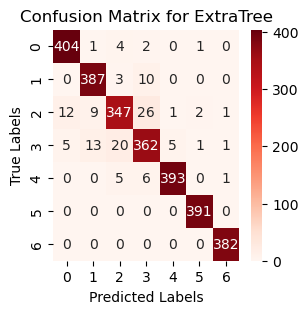

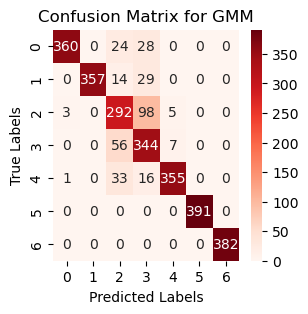

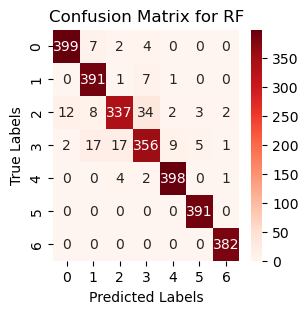

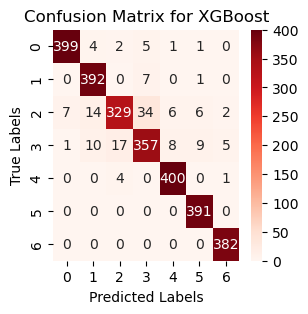

In [16]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you have y_true (true labels) and y_pred (predicted labels)

# 1. Calculate the confusion matrix
cm_ext = confusion_matrix(y_test, y_pred_ext)

# 2. Visualize the confusion matrix using Seaborn
plt.figure(figsize=(3, 3))
sns.heatmap(cm_ext, annot=True, fmt='d', cmap='Reds')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix for ExtraTree')
plt.show()

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you have y_true (true labels) and y_pred (predicted labels)

# 1. Calculate the confusion matrix
cm_gmm = confusion_matrix(y_test, y_pred_gmm)

# 2. Visualize the confusion matrix using Seaborn
plt.figure(figsize=(3, 3))
sns.heatmap(cm_gmm, annot=True, fmt='d', cmap='Reds')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix for GMM')
plt.show()




# 1. Calculate the confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

# 2. Visualize the confusion matrix using Seaborn
plt.figure(figsize=(3, 3))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Reds')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix for RF')
plt.show()



# 1. Calculate the confusion matrix
cm_xg = confusion_matrix(y_test_encoded, y_pred_xg)

# 2. Visualize the confusion matrix using Seaborn
plt.figure(figsize=(3, 3))
sns.heatmap(cm_xg, annot=True, fmt='d', cmap='Reds')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix for XGBoost')
plt.show()




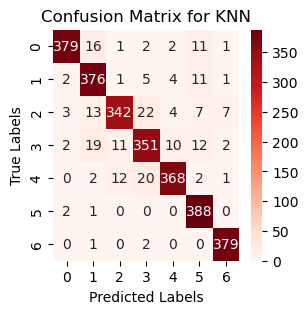

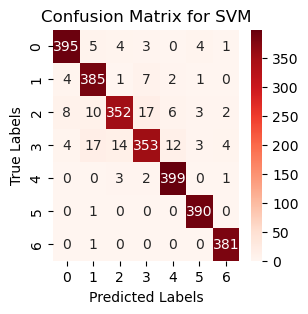

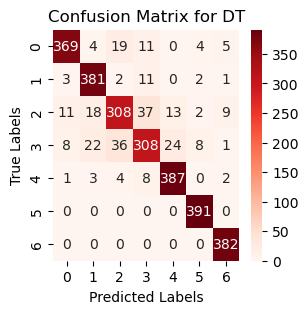

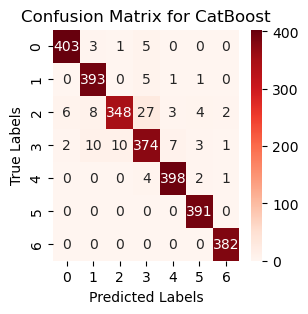

In [17]:
# 1. Calculate the confusion matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)

# 2. Visualize the confusion matrix using Seaborn
plt.figure(figsize=(3, 3))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Reds')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix for KNN')
plt.show()


# 1. Calculate the confusion matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)

# 2. Visualize the confusion matrix using Seaborn
plt.figure(figsize=(3, 3))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Reds')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix for SVM')
plt.show()


# 1. Calculate the confusion matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

# 2. Visualize the confusion matrix using Seaborn
plt.figure(figsize=(3, 3))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Reds')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix for DT')
plt.show()


# 1. Calculate the confusion matrix
cm_cat = confusion_matrix(y_test, y_pred_cat)

# 2. Visualize the confusion matrix using Seaborn
plt.figure(figsize=(3, 3))
sns.heatmap(cm_cat, annot=True, fmt='d', cmap='Reds')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix for CatBoost')
plt.show()

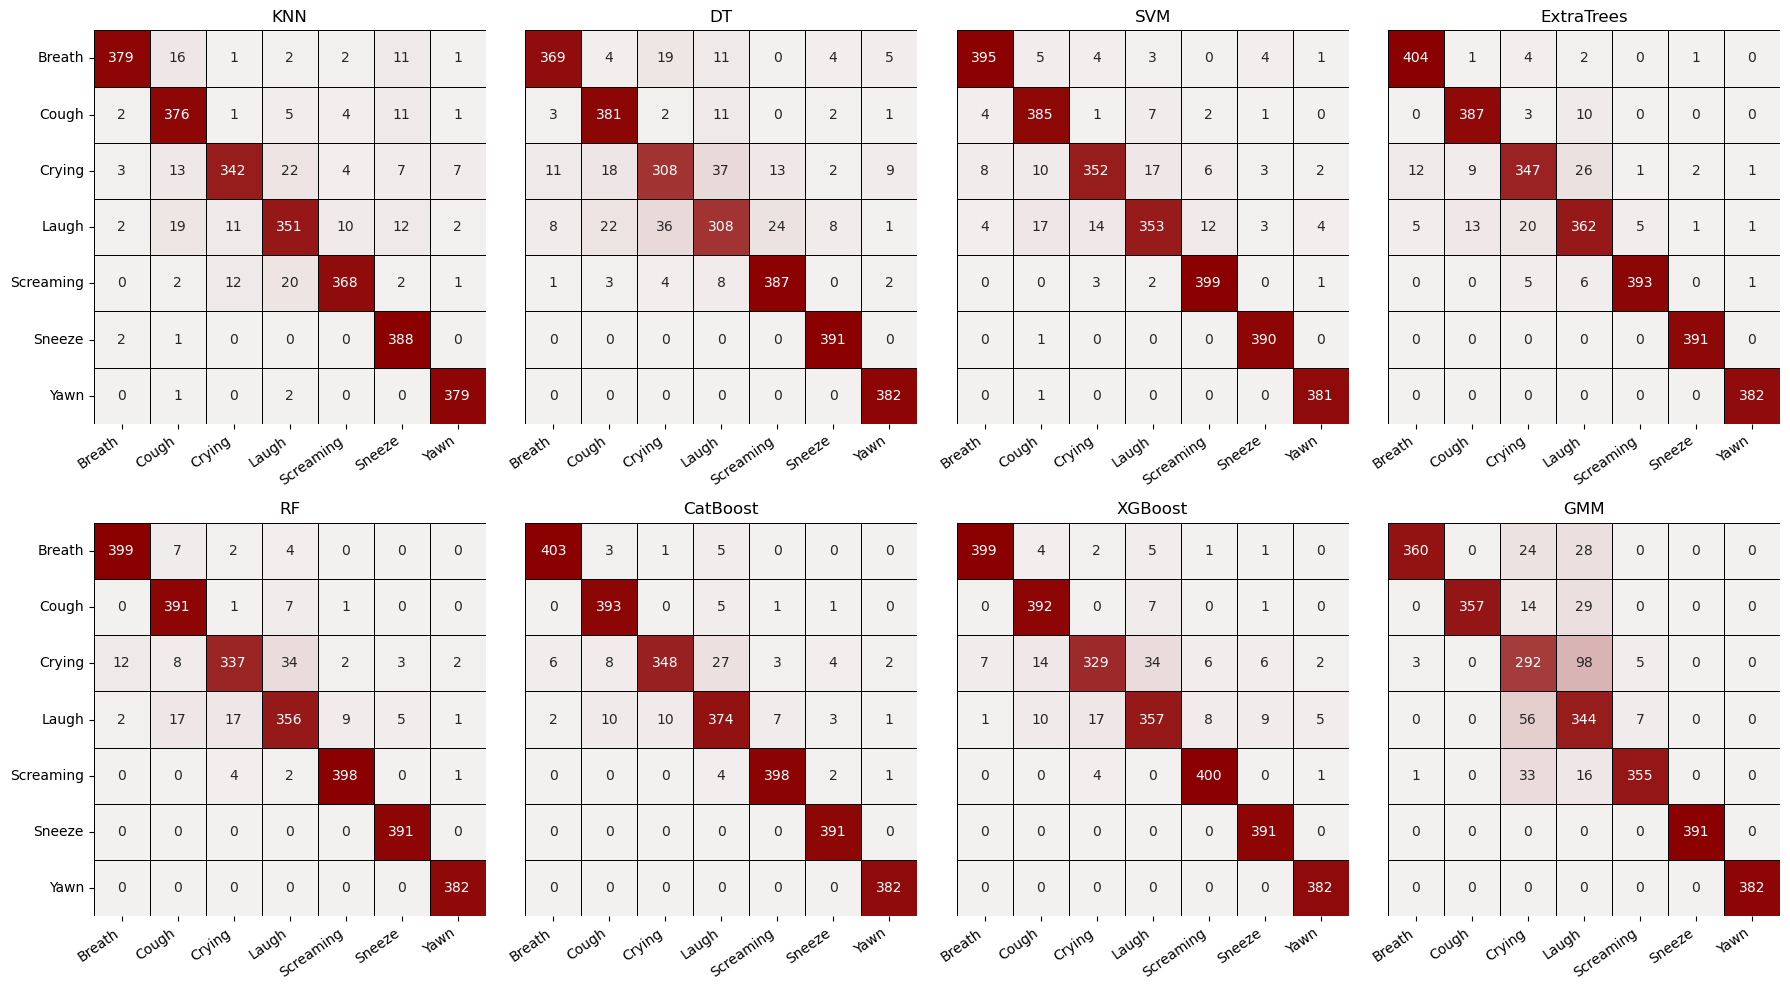

In [18]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
label_names = ['Breath','Cough','Crying','Laugh','Screaming', 'Sneeze', 'Yawn']
classifiers = ["KNN", "DT", "SVM", "ExtraTrees", "RF", "CatBoost", "XGBoost","GMM"]
confusion_matrices = [cm_knn, cm_dt, cm_svm, cm_ext, cm_rf, cm_cat, cm_xg, cm_gmm]

cmap = sns.light_palette("darkred", as_cmap=True)

for i, ax in enumerate(axes.flatten()):
    if i == 0 or i==4:
        sns.heatmap(confusion_matrices[i], annot=True, fmt='d', xticklabels=label_names, yticklabels=label_names,cmap=cmap, linewidths=.6, linecolor='black', ax=ax,cbar=False)
    else:
        sns.heatmap(confusion_matrices[i], annot=True, fmt='d',cmap=cmap, linewidths=.6, linecolor='black', xticklabels=label_names ,yticklabels=False, ax=ax,cbar=False)

    ax.set_title(classifiers[i])
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')


# Adjust layout
plt.tight_layout()
plt.show()

In [4]:
metatrain = pd.read_csv('metadata of train set .csv')
metatrain.head()

,Filename,File ID,Duration in ms,Class ID,Classname,augmentation id,Augmentation type,source
0,108160-1_0_0.wav,108160,3730,0,breath,0,Orignal,https://freesound.org/
1,108160-2_0_0.wav,108160,4000,0,breath,0,Orignal,https://freesound.org/
2,108160-3_0_0.wav,108160,4000,0,breath,0,Orignal,https://freesound.org/
3,108160-4_0_0.wav,108160,2226,0,breath,0,Orignal,https://freesound.org/
4,146769-1_0_0.wav,146769,3540,0,breath,0,Orignal,https://freesound.org/


C:\Users\vaibh\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\vaibh\anaconda3\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\vaibh\anaconda3\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\vaibh\anaconda3\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a len

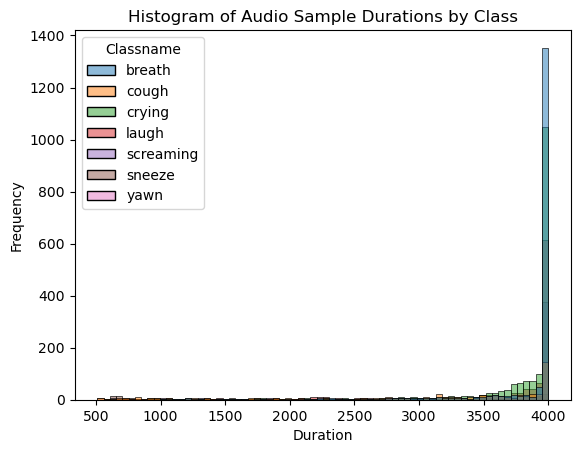

In [20]:
import seaborn as sns
sns.histplot(data=metatrain, x='Duration in ms', hue='Classname')
plt.xlabel('Duration')
plt.ylabel('Frequency')
plt.title('Histogram of Audio Sample Durations by Class')
plt.show()

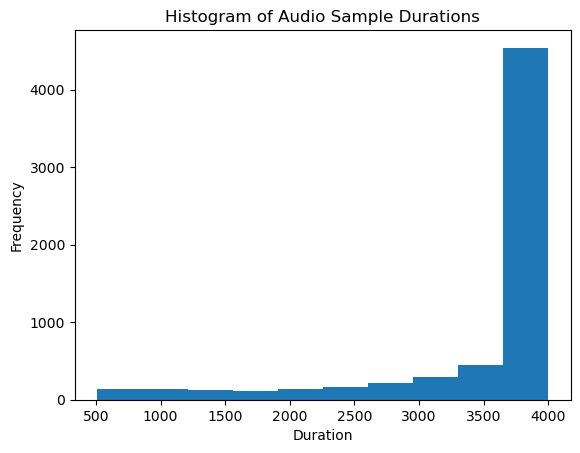

In [21]:
import matplotlib.pyplot as plt
plt.hist(metatrain['Duration in ms'])
plt.xlabel('Duration')
plt.ylabel('Frequency')
plt.title('Histogram of Audio Sample Durations')
plt.show()

C:\Users\vaibh\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\vaibh\anaconda3\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\vaibh\anaconda3\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\vaibh\anaconda3\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a len

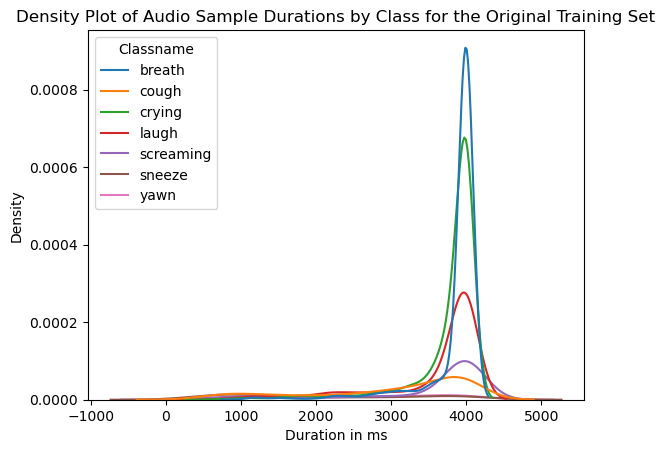

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(data=metatrain, x='Duration in ms', hue='Classname')
plt.xlabel('Duration in ms')
plt.ylabel('Density')
plt.title('Density Plot of Audio Sample Durations by Class for the Original Training Set')
plt.show()

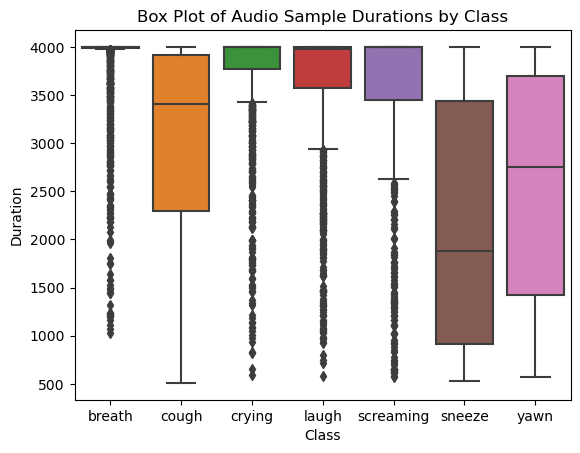

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=metatrain, x='Classname', y='Duration in ms')
plt.xlabel('Class')
plt.ylabel('Duration')
plt.title('Box Plot of Audio Sample Durations by Class')
plt.show()

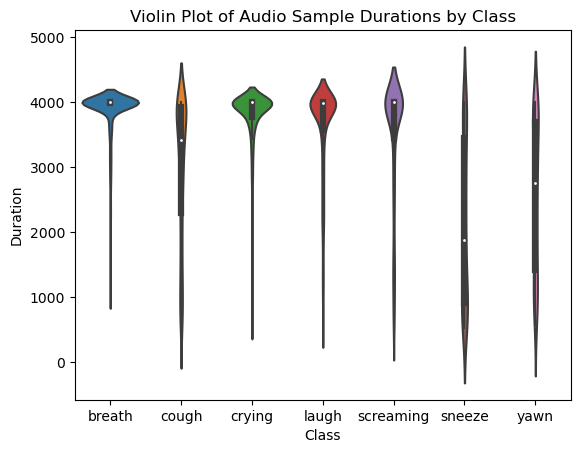

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.violinplot(data=metatrain, x='Classname', y='Duration in ms')
plt.xlabel('Class')
plt.ylabel('Duration')
plt.title('Violin Plot of Audio Sample Durations by Class')
plt.show()

C:\Users\vaibh\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\vaibh\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\vaibh\anaconda3\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


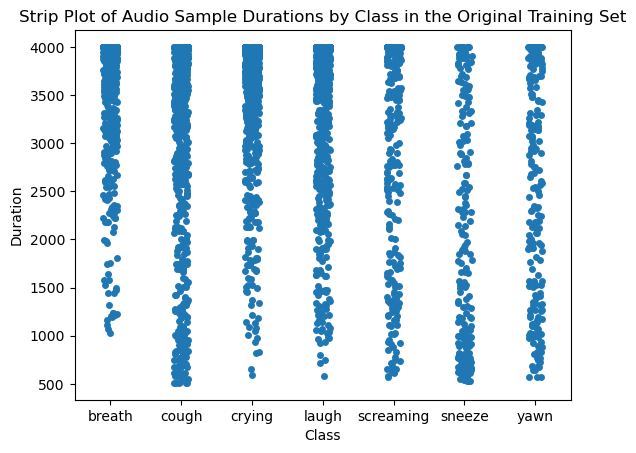

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.stripplot(data=metatrain, x='Classname', y='Duration in ms', jitter=True)
plt.xlabel('Class')
plt.ylabel('Duration')
plt.title('Strip Plot of Audio Sample Durations by Class in the Original Training Set')
plt.show()

C:\Users\vaibh\AppData\Local\Temp\ipykernel_26480\842533058.py:10: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  ax = sns.stripplot(data=metatrain, x='Classname', y='Duration in ms', jitter=0.2, size=2, palette="husl")
C:\Users\vaibh\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\vaibh\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


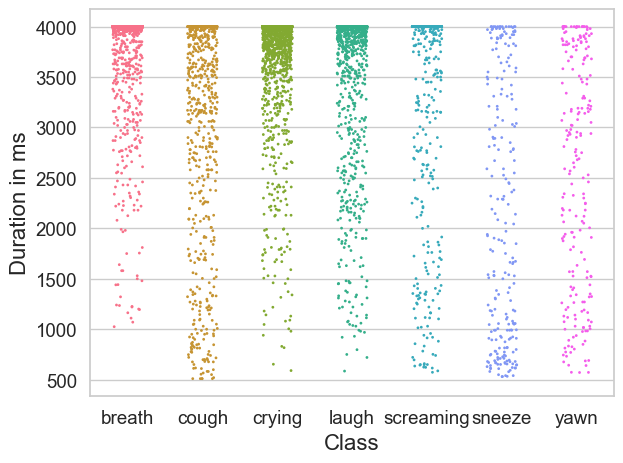

<Figure size 400x200 with 0 Axes>

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set a visually appealing style
sns.set_theme(style="whitegrid")

# Create the strip plot with customization
# ax = sns.stripplot(data=metatrain, x='Classname', y='Duration in ms', jitter=0.2, size=2, palette="husl")

ax = sns.stripplot(data=metatrain, x='Classname', y='Duration in ms', jitter=0.2, size=2, palette="husl")

# Set labels and title
plt.xlabel('Class', fontsize=16)
plt.ylabel('Duration in ms', fontsize=16)
# plt.title('Strip Plot of Audio Sample Durations by Class for the Original Training Set', fontsize=14)

ax.tick_params(axis='both', which='major', labelsize=13.5)

# Adjust plot layout for better spacing
plt.tight_layout()


plt.figure(figsize=(4, 2))

# Display the plot
plt.show()

In [35]:
original_width, original_height = plt.rcParams['figure.figsize']

# Scale the width and height by 0.71 (square root of 0.5)
new_width = original_width * 0.71
new_height = original_height * 0.71

# Set the new figure size
plt.figure(figsize=(new_width, new_height))

# ... (rest of your plotting code) ...

plt.show()

<Figure size 454.4x340.8 with 0 Axes>

In [7]:
metatest = pd.read_csv('metadata of test set.csv')
metatest.head()

,Filename,File_ID,Durationin ms,Class_id,Classname,Augment Id,Augmentation type,source
0,112557-2_0_0.wav,112557,4000,0,breath,0,Original,https://freesound.org/
1,112557-3_0_0.wav,112557,3950,0,breath,0,Original,https://freesound.org/
2,112557-4_0_0.wav,112557,3910,0,breath,0,Original,https://freesound.org/
3,140301_0_0.wav,140301,2261,0,breath,0,Original,https://freesound.org/
4,144128-1_0_0.wav,144128,3770,0,breath,0,Original,https://freesound.org/


C:\Users\vaibh\AppData\Local\Temp\ipykernel_26480\4025425898.py:8: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  ax = sns.stripplot(data=metatest, x='Classname', y='Durationin ms', jitter=0.2, size=2, palette="husl")
C:\Users\vaibh\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\vaibh\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


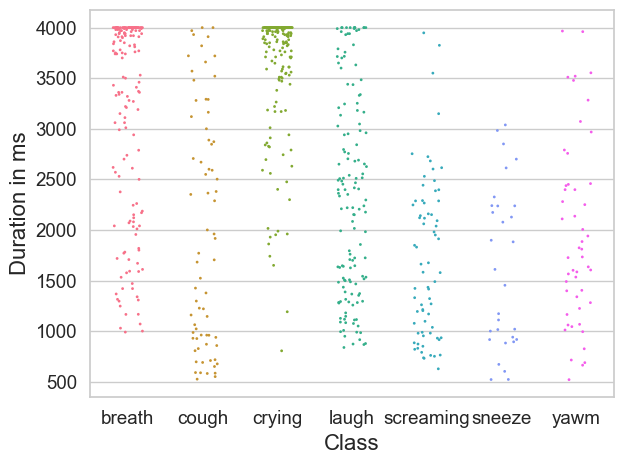

<Figure size 400x200 with 0 Axes>

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set a visually appealing style
sns.set_theme(style="whitegrid")

# Create the strip plot with customization
ax = sns.stripplot(data=metatest, x='Classname', y='Durationin ms', jitter=0.2, size=2, palette="husl")

# Set labels and title
plt.xlabel('Class', fontsize=16)
plt.ylabel('Duration in ms', fontsize=16)
# plt.title('Strip Plot of Audio Sample Durations by Class for the Original Testing Set', fontsize=14)

ax.tick_params(axis='both', which='major', labelsize=13.5)


# Adjust plot layout for better spacing

plt.tight_layout()

plt.figure(figsize=(4, 2))

# Display the plot
plt.show()

C:\Users\vaibh\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\vaibh\anaconda3\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\vaibh\anaconda3\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\vaibh\anaconda3\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a len

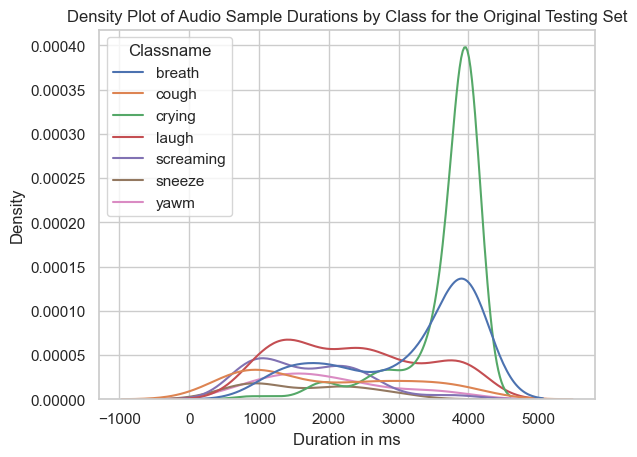

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(data=metatest, x='Durationin ms', hue='Classname')
plt.xlabel('Duration in ms')
plt.ylabel('Density')
plt.title('Density Plot of Audio Sample Durations by Class for the Original Testing Set')
plt.show()

File Path:-  C:/Users/vaibh/Desktop/Desktop/Coding/Machine_Learning/Non-speech-detection/6967442/train/train/wbgA6VrNtsw-60_3_0.wav
**********************************************************************************************




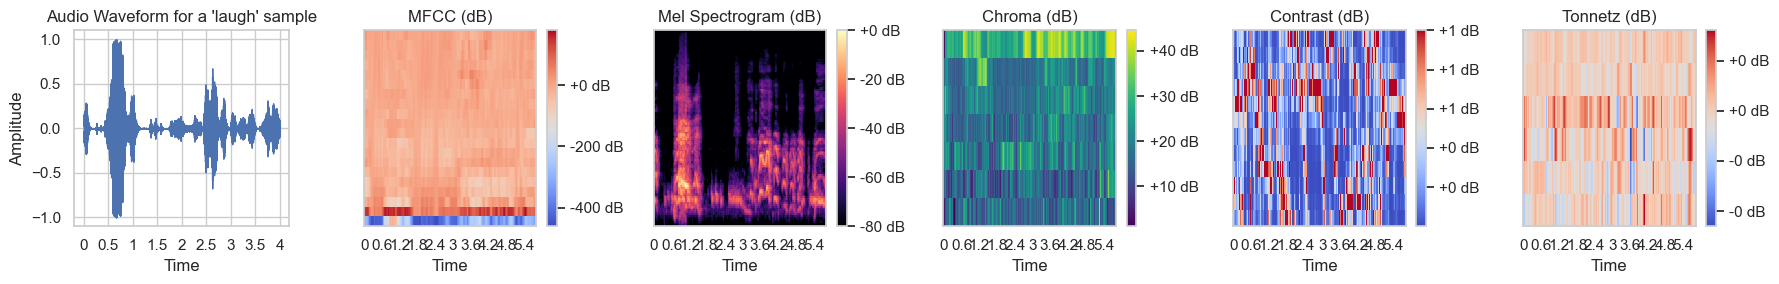

File Path:-  C:/Users/vaibh/Desktop/Desktop/Coding/Machine_Learning/Non-speech-detection/6967442/train/train/486666-6_3_0.wav
**********************************************************************************************




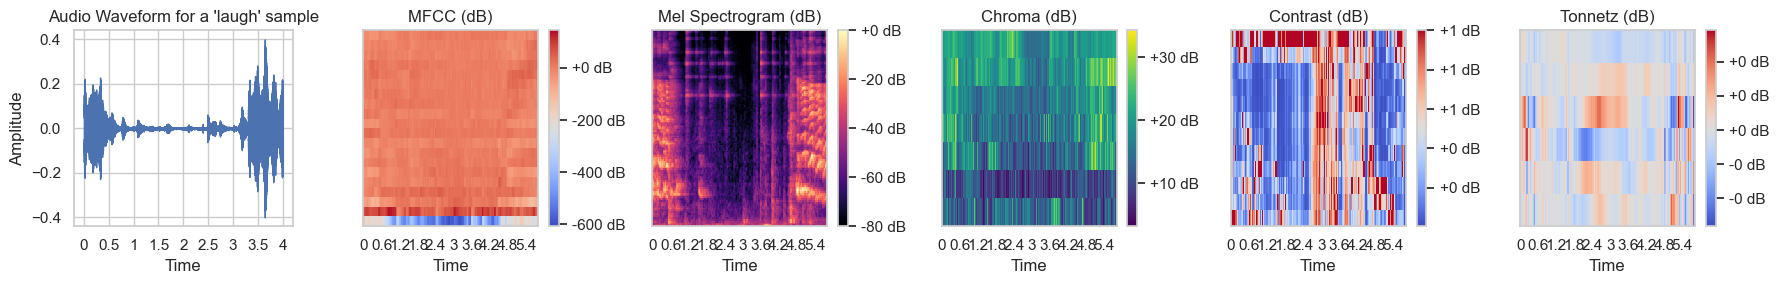

In [30]:
class_samples = metatrain[metatrain['Classname'] == "laugh"].sample(2)
train_path= 'C:/Users/vaibh/Desktop/Desktop/Coding/Machine_Learning/Non-speech-detection/6967442/train/train/'
for index, row in class_samples.iterrows():
  filename = row['Filename']
  file_path = train_path + filename
  print("File Path:- ", file_path)
  print("**********************************************************************************************")
  print("\n")
  # Load audio
  y, sr = librosa.load(file_path, sr=None)

  # Extract features
  mfccs = librosa.feature.mfcc(y=y, sr=sr)
  mel = librosa.feature.melspectrogram(y=y, sr=sr)
  contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
  chroma = librosa.feature.chroma_stft(y=y, sr=sr)
  tonnetz = librosa.feature.tonnetz(y=y, sr=sr)

  if mfccs is not None:

      # Plot audio waveform
      plt.figure(figsize=(18, 3))

      plt.subplot(1, 6, 1)
      librosa.display.waveshow(y, sr=sr)
      plt.title('Audio Waveform for a \'laugh\' sample')
      plt.xlabel('Time')
      plt.ylabel('Amplitude')

      plt.subplot(1, 6, 2)
      librosa.display.specshow(mfccs, x_axis='time')
      plt.colorbar(format='%+2.0f dB')
      plt.title('MFCC (dB)')
      plt.xlabel('Time')
      plt.gca().axes.get_yaxis().set_visible(False)

      plt.subplot(1, 6, 3)
      librosa.display.specshow(librosa.power_to_db(mel, ref=np.max), x_axis='time', y_axis='mel')
      plt.colorbar(format='%+2.0f dB')
      plt.title('Mel Spectrogram (dB)')
      plt.xlabel('Time')
      plt.gca().axes.get_yaxis().set_visible(False)

      plt.subplot(1, 6, 4)
      librosa.display.specshow(contrast, x_axis='time', cmap='viridis')
      plt.colorbar(format='%+2.0f dB')
      plt.title('Chroma (dB)')
      plt.xlabel('Time')
      plt.gca().axes.get_yaxis().set_visible(False)

      plt.subplot(1, 6, 5)
      librosa.display.specshow(chroma, x_axis='time', y_axis='chroma', cmap='coolwarm')
      plt.colorbar(format='%+2.0f dB')
      plt.title('Contrast (dB)')
      plt.xlabel('Time')
      plt.gca().axes.get_yaxis().set_visible(False)

      plt.subplot(1, 6, 6)
      librosa.display.specshow(tonnetz, x_axis='time')
      plt.colorbar(format='%+2.0f dB')
      plt.title('Tonnetz (dB)')
      plt.xlabel('Time')
      plt.gca().axes.get_yaxis().set_visible(False)

      plt.tight_layout()

      plot_filename = "laugh_.png"
      plt.savefig(plot_filename)

      plt.show()


File Path:-  C:/Users/vaibh/Desktop/Desktop/Coding/Machine_Learning/Non-speech-detection/6967442/train/train/151080-16_2_0.wav
**********************************************************************************************




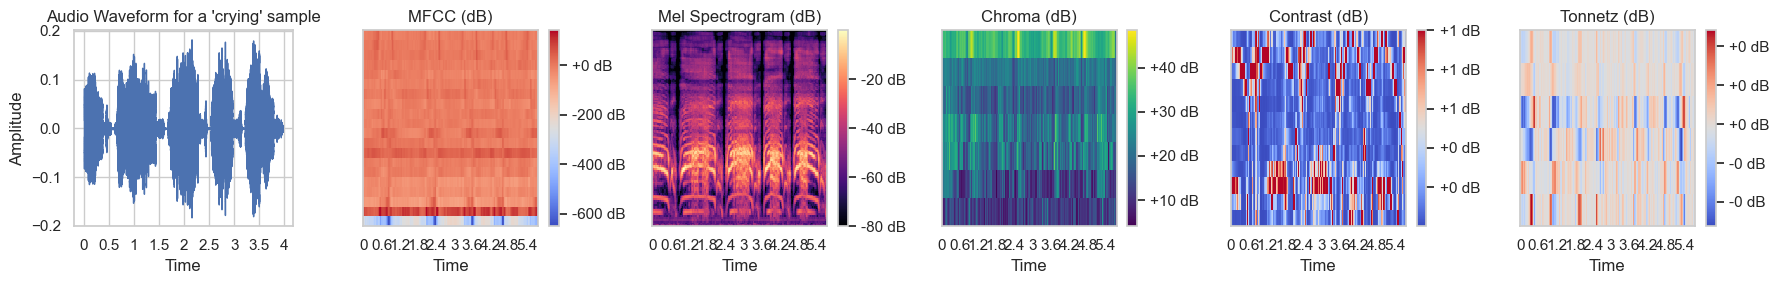

File Path:-  C:/Users/vaibh/Desktop/Desktop/Coding/Machine_Learning/Non-speech-detection/6967442/train/train/46=363149-20_2_0.wav
**********************************************************************************************




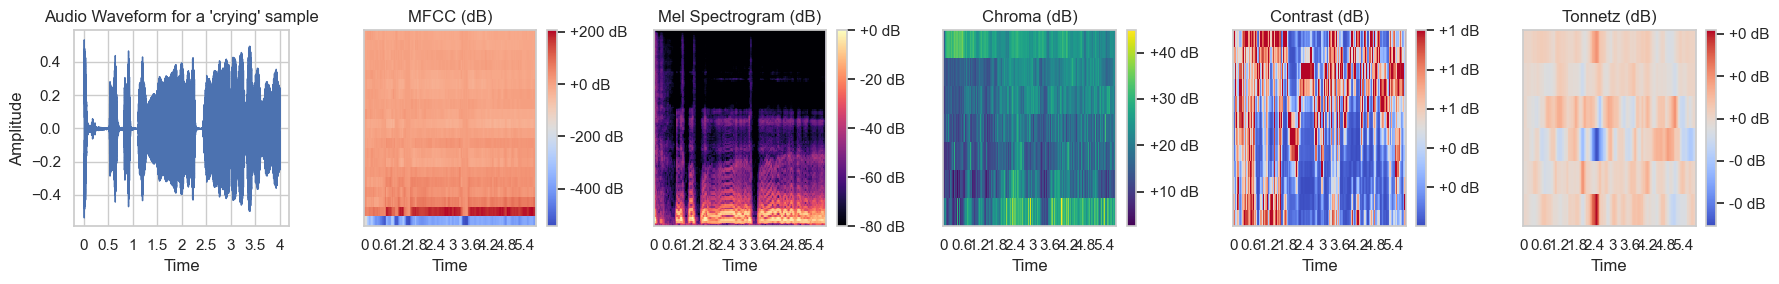

In [31]:
class_samples = metatrain[metatrain['Classname'] == "crying"].sample(2)
train_path= 'C:/Users/vaibh/Desktop/Desktop/Coding/Machine_Learning/Non-speech-detection/6967442/train/train/'
for index, row in class_samples.iterrows():
  filename = row['Filename']
  file_path = train_path + filename
  print("File Path:- ", file_path)
  print("**********************************************************************************************")
  print("\n")
  # Load audio
  y, sr = librosa.load(file_path, sr=None)

  # Extract features
  mfccs = librosa.feature.mfcc(y=y, sr=sr)
  mel = librosa.feature.melspectrogram(y=y, sr=sr)
  contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
  chroma = librosa.feature.chroma_stft(y=y, sr=sr)
  tonnetz = librosa.feature.tonnetz(y=y, sr=sr)

  if mfccs is not None:

      # Plot audio waveform
      plt.figure(figsize=(18, 3))

      plt.subplot(1, 6, 1)
      librosa.display.waveshow(y, sr=sr)
      plt.title('Audio Waveform for a \'crying\' sample')
      plt.xlabel('Time')
      plt.ylabel('Amplitude')

      plt.subplot(1, 6, 2)
      librosa.display.specshow(mfccs, x_axis='time')
      plt.colorbar(format='%+2.0f dB')
      plt.title('MFCC (dB)')
      plt.xlabel('Time')
      plt.gca().axes.get_yaxis().set_visible(False)

      plt.subplot(1, 6, 3)
      librosa.display.specshow(librosa.power_to_db(mel, ref=np.max), x_axis='time', y_axis='mel')
      plt.colorbar(format='%+2.0f dB')
      plt.title('Mel Spectrogram (dB)')
      plt.xlabel('Time')
      plt.gca().axes.get_yaxis().set_visible(False)

      plt.subplot(1, 6, 4)
      librosa.display.specshow(contrast, x_axis='time', cmap='viridis')
      plt.colorbar(format='%+2.0f dB')
      plt.title('Chroma (dB)')
      plt.xlabel('Time')
      plt.gca().axes.get_yaxis().set_visible(False)

      plt.subplot(1, 6, 5)
      librosa.display.specshow(chroma, x_axis='time', y_axis='chroma', cmap='coolwarm')
      plt.colorbar(format='%+2.0f dB')
      plt.title('Contrast (dB)')
      plt.xlabel('Time')
      plt.gca().axes.get_yaxis().set_visible(False)

      plt.subplot(1, 6, 6)
      librosa.display.specshow(tonnetz, x_axis='time')
      plt.colorbar(format='%+2.0f dB')
      plt.title('Tonnetz (dB)')
      plt.xlabel('Time')
      plt.gca().axes.get_yaxis().set_visible(False)

      plt.tight_layout()

      plot_filename = "crying_.png"
      plt.savefig(plot_filename)

      plt.show()


File Path:-  C:/Users/vaibh/Desktop/Desktop/Coding/Machine_Learning/Non-speech-detection/6967442/train/train/483564-1_1_0.wav
**********************************************************************************************




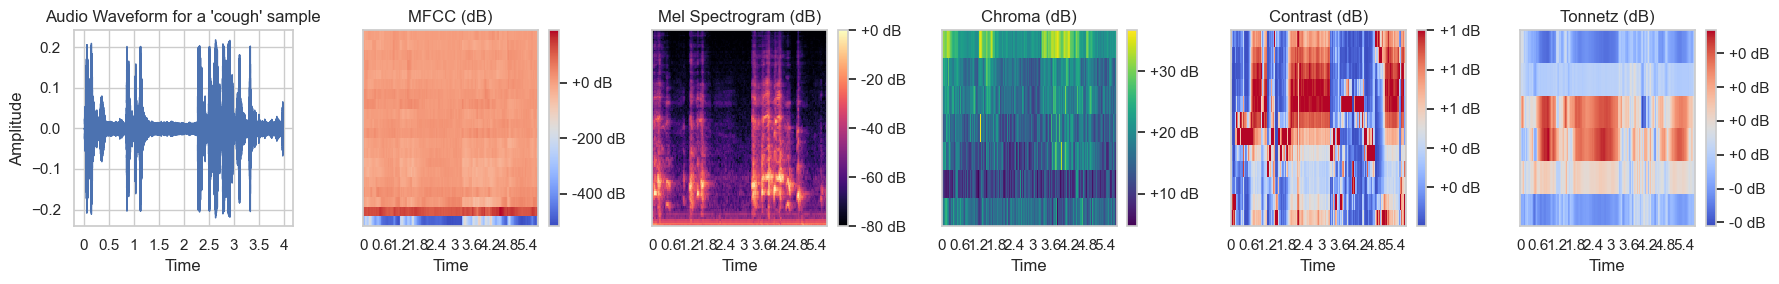

File Path:-  C:/Users/vaibh/Desktop/Desktop/Coding/Machine_Learning/Non-speech-detection/6967442/train/train/191-cough-aigei_1_0.wav
**********************************************************************************************




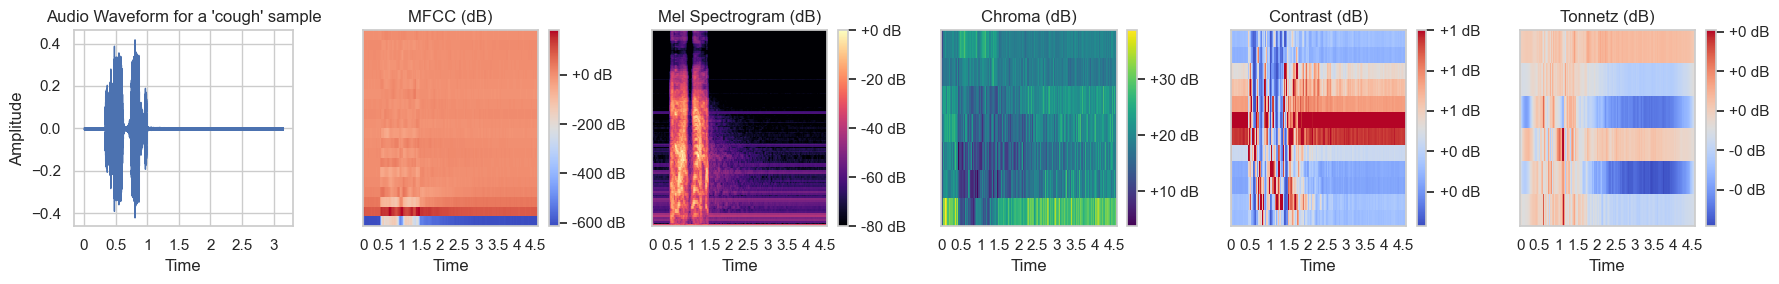

In [32]:
class_samples = metatrain[metatrain['Classname'] == "cough"].sample(2)
train_path= 'C:/Users/vaibh/Desktop/Desktop/Coding/Machine_Learning/Non-speech-detection/6967442/train/train/'
for index, row in class_samples.iterrows():
  filename = row['Filename']
  file_path = train_path + filename
  print("File Path:- ", file_path)
  print("**********************************************************************************************")
  print("\n")
  # Load audio
  y, sr = librosa.load(file_path, sr=None)

  # Extract features
  mfccs = librosa.feature.mfcc(y=y, sr=sr)
  mel = librosa.feature.melspectrogram(y=y, sr=sr)
  contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
  chroma = librosa.feature.chroma_stft(y=y, sr=sr)
  tonnetz = librosa.feature.tonnetz(y=y, sr=sr)

  if mfccs is not None:

      # Plot audio waveform
      plt.figure(figsize=(18, 3))

      plt.subplot(1, 6, 1)
      librosa.display.waveshow(y, sr=sr)
      plt.title('Audio Waveform for a \'cough\' sample')
      plt.xlabel('Time')
      plt.ylabel('Amplitude')

      plt.subplot(1, 6, 2)
      librosa.display.specshow(mfccs, x_axis='time')
      plt.colorbar(format='%+2.0f dB')
      plt.title('MFCC (dB)')
      plt.xlabel('Time')
      plt.gca().axes.get_yaxis().set_visible(False)

      plt.subplot(1, 6, 3)
      librosa.display.specshow(librosa.power_to_db(mel, ref=np.max), x_axis='time', y_axis='mel')
      plt.colorbar(format='%+2.0f dB')
      plt.title('Mel Spectrogram (dB)')
      plt.xlabel('Time')
      plt.gca().axes.get_yaxis().set_visible(False)

      plt.subplot(1, 6, 4)
      librosa.display.specshow(contrast, x_axis='time', cmap='viridis')
      plt.colorbar(format='%+2.0f dB')
      plt.title('Chroma (dB)')
      plt.xlabel('Time')
      plt.gca().axes.get_yaxis().set_visible(False)

      plt.subplot(1, 6, 5)
      librosa.display.specshow(chroma, x_axis='time', y_axis='chroma', cmap='coolwarm')
      plt.colorbar(format='%+2.0f dB')
      plt.title('Contrast (dB)')
      plt.xlabel('Time')
      plt.gca().axes.get_yaxis().set_visible(False)

      plt.subplot(1, 6, 6)
      librosa.display.specshow(tonnetz, x_axis='time')
      plt.colorbar(format='%+2.0f dB')
      plt.title('Tonnetz (dB)')
      plt.xlabel('Time')
      plt.gca().axes.get_yaxis().set_visible(False)

      plt.tight_layout()

      plot_filename = "cough_.png"
      plt.savefig(plot_filename)

      plt.show()


File Path:-  C:/Users/vaibh/Desktop/Desktop/Coding/Machine_Learning/Non-speech-detection/6967442/train/train/150231_5_0.wav
**********************************************************************************************




C:\Users\vaibh\anaconda3\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=647
  warnings.warn(
C:\Users\vaibh\anaconda3\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=324
  warnings.warn(


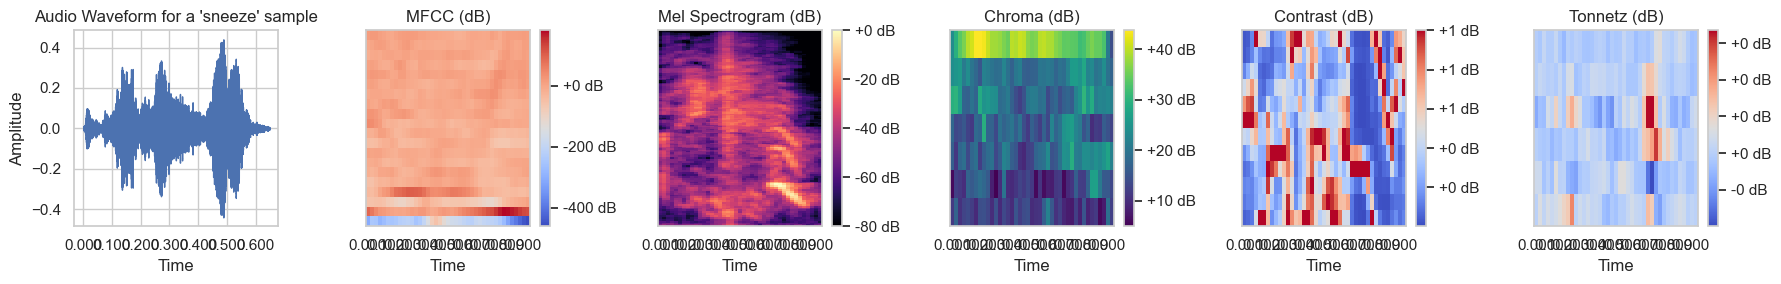

File Path:-  C:/Users/vaibh/Desktop/Desktop/Coding/Machine_Learning/Non-speech-detection/6967442/train/train/56-sneeze-aigei-1_5_0.wav
**********************************************************************************************




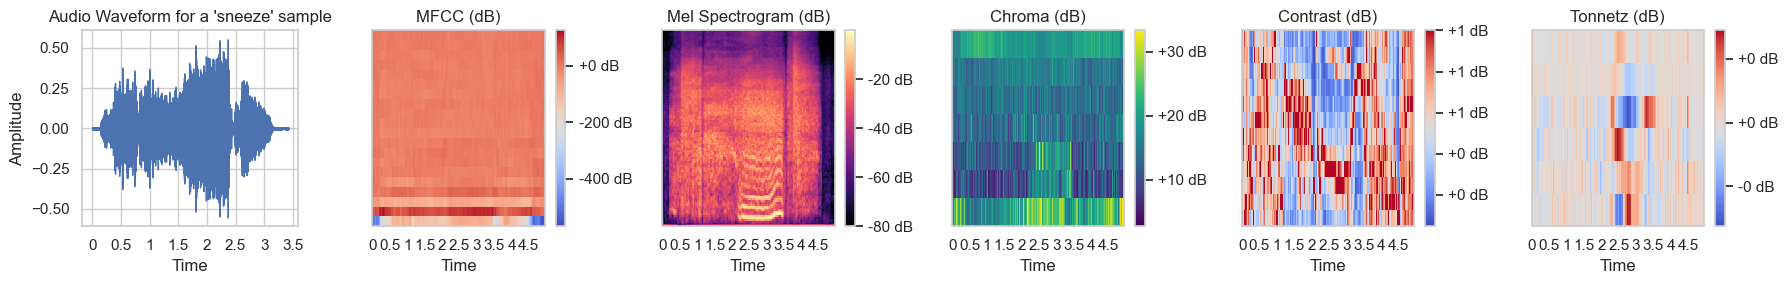

In [33]:
class_samples = metatrain[metatrain['Classname'] == "sneeze"].sample(2)
train_path= 'C:/Users/vaibh/Desktop/Desktop/Coding/Machine_Learning/Non-speech-detection/6967442/train/train/'
for index, row in class_samples.iterrows():
  filename = row['Filename']
  file_path = train_path + filename
  print("File Path:- ", file_path)
  print("**********************************************************************************************")
  print("\n")
  # Load audio
  y, sr = librosa.load(file_path, sr=None)

  # Extract features
  mfccs = librosa.feature.mfcc(y=y, sr=sr)
  mel = librosa.feature.melspectrogram(y=y, sr=sr)
  contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
  chroma = librosa.feature.chroma_stft(y=y, sr=sr)
  tonnetz = librosa.feature.tonnetz(y=y, sr=sr)

  if mfccs is not None:

      # Plot audio waveform
      plt.figure(figsize=(18, 3))

      plt.subplot(1, 6, 1)
      librosa.display.waveshow(y, sr=sr)
      plt.title('Audio Waveform for a \'sneeze\' sample')
      plt.xlabel('Time')
      plt.ylabel('Amplitude')

      plt.subplot(1, 6, 2)
      librosa.display.specshow(mfccs, x_axis='time')
      plt.colorbar(format='%+2.0f dB')
      plt.title('MFCC (dB)')
      plt.xlabel('Time')
      plt.gca().axes.get_yaxis().set_visible(False)

      plt.subplot(1, 6, 3)
      librosa.display.specshow(librosa.power_to_db(mel, ref=np.max), x_axis='time', y_axis='mel')
      plt.colorbar(format='%+2.0f dB')
      plt.title('Mel Spectrogram (dB)')
      plt.xlabel('Time')
      plt.gca().axes.get_yaxis().set_visible(False)

      plt.subplot(1, 6, 4)
      librosa.display.specshow(contrast, x_axis='time', cmap='viridis')
      plt.colorbar(format='%+2.0f dB')
      plt.title('Chroma (dB)')
      plt.xlabel('Time')
      plt.gca().axes.get_yaxis().set_visible(False)

      plt.subplot(1, 6, 5)
      librosa.display.specshow(chroma, x_axis='time', y_axis='chroma', cmap='coolwarm')
      plt.colorbar(format='%+2.0f dB')
      plt.title('Contrast (dB)')
      plt.xlabel('Time')
      plt.gca().axes.get_yaxis().set_visible(False)

      plt.subplot(1, 6, 6)
      librosa.display.specshow(tonnetz, x_axis='time')
      plt.colorbar(format='%+2.0f dB')
      plt.title('Tonnetz (dB)')
      plt.xlabel('Time')
      plt.gca().axes.get_yaxis().set_visible(False)

      plt.tight_layout()

      plot_filename = "sneeze_.png"
      plt.savefig(plot_filename)

      plt.show()


File Path:-  C:/Users/vaibh/Desktop/Desktop/Coding/Machine_Learning/Non-speech-detection/6967442/train/train/k8fI3Kkm3GM-197_0_0.wav
**********************************************************************************************




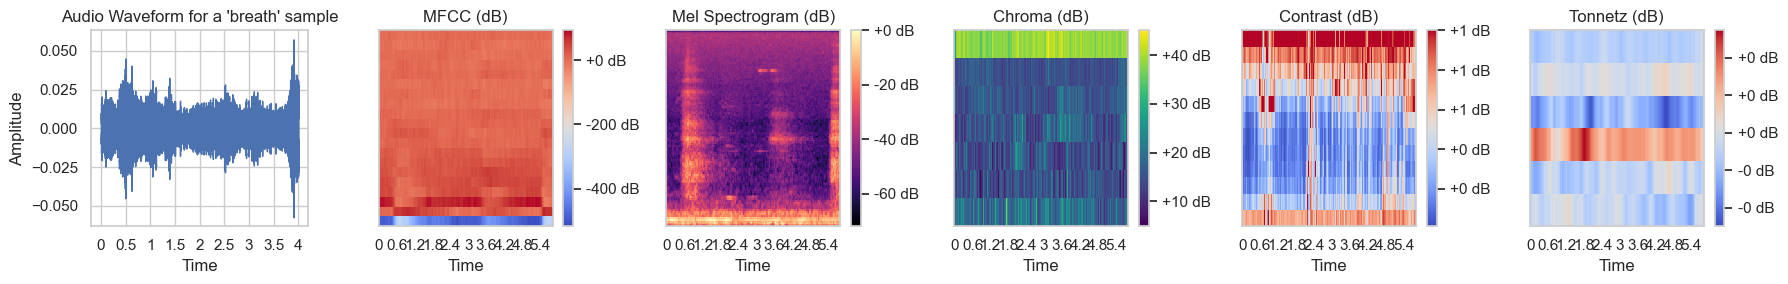

File Path:-  C:/Users/vaibh/Desktop/Desktop/Coding/Machine_Learning/Non-speech-detection/6967442/train/train/k8fI3Kkm3GM-437_0_0.wav
**********************************************************************************************




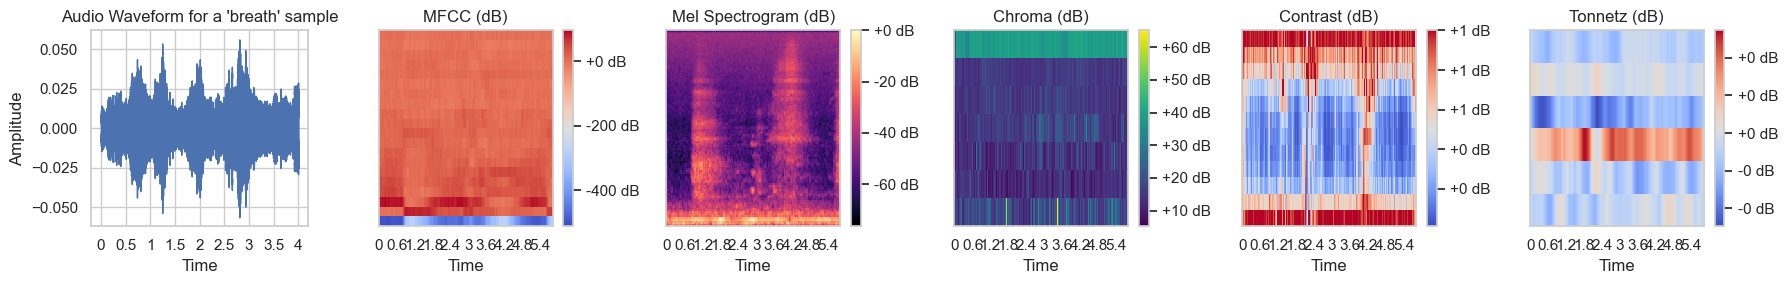

In [34]:
class_samples = metatrain[metatrain['Classname'] == "breath"].sample(2)
train_path= 'C:/Users/vaibh/Desktop/Desktop/Coding/Machine_Learning/Non-speech-detection/6967442/train/train/'
for index, row in class_samples.iterrows():
  filename = row['Filename']
  file_path = train_path + filename
  print("File Path:- ", file_path)
  print("**********************************************************************************************")
  print("\n")
  # Load audio
  y, sr = librosa.load(file_path, sr=None)

  # Extract features
  mfccs = librosa.feature.mfcc(y=y, sr=sr)
  mel = librosa.feature.melspectrogram(y=y, sr=sr)
  contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
  chroma = librosa.feature.chroma_stft(y=y, sr=sr)
  tonnetz = librosa.feature.tonnetz(y=y, sr=sr)

  if mfccs is not None:

      # Plot audio waveform
      plt.figure(figsize=(18, 3))

      plt.subplot(1, 6, 1)
      librosa.display.waveshow(y, sr=sr)
      plt.title('Audio Waveform for a \'breath\' sample')
      plt.xlabel('Time')
      plt.ylabel('Amplitude')

      plt.subplot(1, 6, 2)
      librosa.display.specshow(mfccs, x_axis='time')
      plt.colorbar(format='%+2.0f dB')
      plt.title('MFCC (dB)')
      plt.xlabel('Time')
      plt.gca().axes.get_yaxis().set_visible(False)

      plt.subplot(1, 6, 3)
      librosa.display.specshow(librosa.power_to_db(mel, ref=np.max), x_axis='time', y_axis='mel')
      plt.colorbar(format='%+2.0f dB')
      plt.title('Mel Spectrogram (dB)')
      plt.xlabel('Time')
      plt.gca().axes.get_yaxis().set_visible(False)

      plt.subplot(1, 6, 4)
      librosa.display.specshow(contrast, x_axis='time', cmap='viridis')
      plt.colorbar(format='%+2.0f dB')
      plt.title('Chroma (dB)')
      plt.xlabel('Time')
      plt.gca().axes.get_yaxis().set_visible(False)

      plt.subplot(1, 6, 5)
      librosa.display.specshow(chroma, x_axis='time', y_axis='chroma', cmap='coolwarm')
      plt.colorbar(format='%+2.0f dB')
      plt.title('Contrast (dB)')
      plt.xlabel('Time')
      plt.gca().axes.get_yaxis().set_visible(False)

      plt.subplot(1, 6, 6)
      librosa.display.specshow(tonnetz, x_axis='time')
      plt.colorbar(format='%+2.0f dB')
      plt.title('Tonnetz (dB)')
      plt.xlabel('Time')
      plt.gca().axes.get_yaxis().set_visible(False)

      plt.tight_layout()

      plot_filename = "breath_.png"
      plt.savefig(plot_filename)

      plt.show()


File Path:-  C:/Users/vaibh/Desktop/Desktop/Coding/Machine_Learning/Non-speech-detection/6967442/train/train/157303-1_6_0.wav
**********************************************************************************************




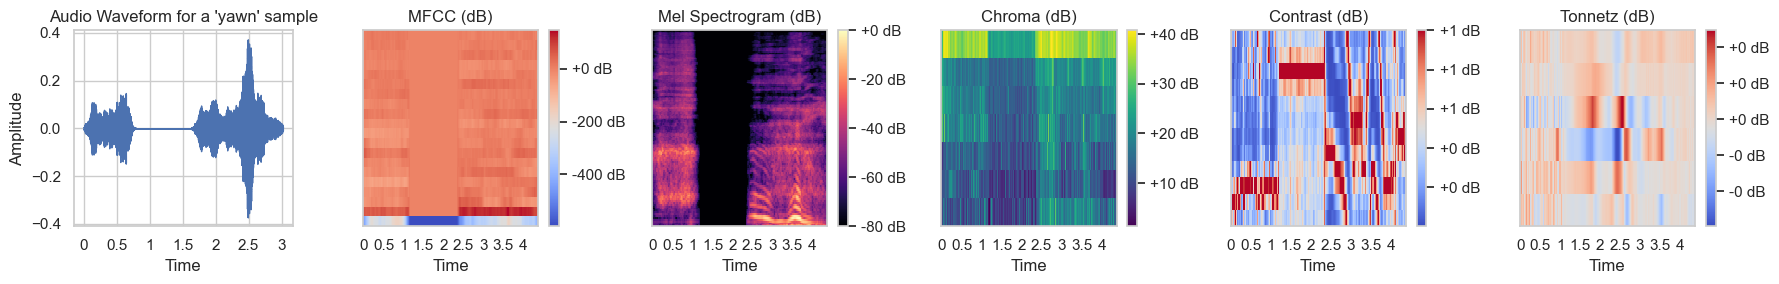

File Path:-  C:/Users/vaibh/Desktop/Desktop/Coding/Machine_Learning/Non-speech-detection/6967442/train/train/317845-7_6_0.wav
**********************************************************************************************




C:\Users\vaibh\anaconda3\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=890
  warnings.warn(
C:\Users\vaibh\anaconda3\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=445
  warnings.warn(


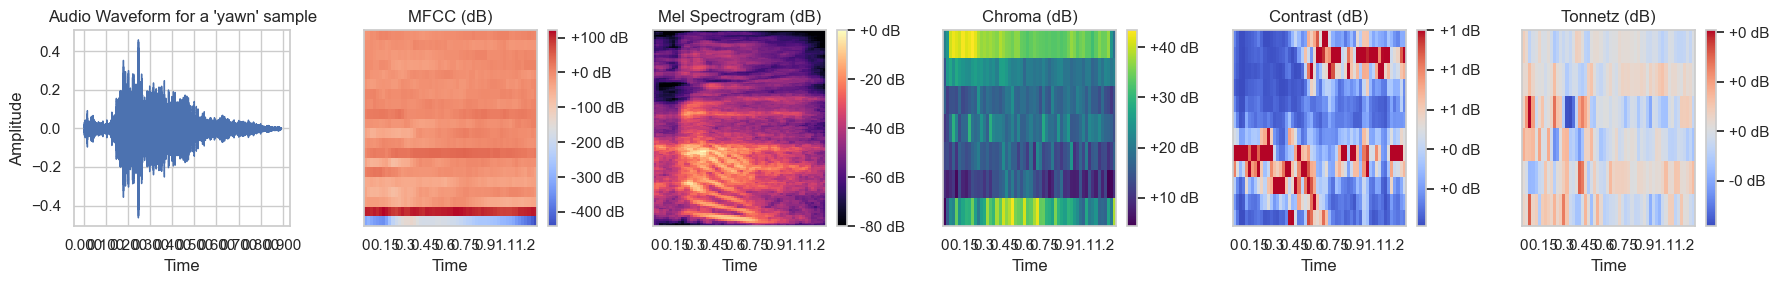

In [35]:
class_samples = metatrain[metatrain['Classname'] == "yawn"].sample(2)
train_path= 'C:/Users/vaibh/Desktop/Desktop/Coding/Machine_Learning/Non-speech-detection/6967442/train/train/'
for index, row in class_samples.iterrows():
  filename = row['Filename']
  file_path = train_path + filename
  print("File Path:- ", file_path)
  print("**********************************************************************************************")
  print("\n")
  # Load audio
  y, sr = librosa.load(file_path, sr=None)

  # Extract features
  mfccs = librosa.feature.mfcc(y=y, sr=sr)
  mel = librosa.feature.melspectrogram(y=y, sr=sr)
  contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
  chroma = librosa.feature.chroma_stft(y=y, sr=sr)
  tonnetz = librosa.feature.tonnetz(y=y, sr=sr)

  if mfccs is not None:

      # Plot audio waveform
      plt.figure(figsize=(18, 3))

      plt.subplot(1, 6, 1)
      librosa.display.waveshow(y, sr=sr)
      plt.title('Audio Waveform for a \'yawn\' sample')
      plt.xlabel('Time')
      plt.ylabel('Amplitude')

      plt.subplot(1, 6, 2)
      librosa.display.specshow(mfccs, x_axis='time')
      plt.colorbar(format='%+2.0f dB')
      plt.title('MFCC (dB)')
      plt.xlabel('Time')
      plt.gca().axes.get_yaxis().set_visible(False)

      plt.subplot(1, 6, 3)
      librosa.display.specshow(librosa.power_to_db(mel, ref=np.max), x_axis='time', y_axis='mel')
      plt.colorbar(format='%+2.0f dB')
      plt.title('Mel Spectrogram (dB)')
      plt.xlabel('Time')
      plt.gca().axes.get_yaxis().set_visible(False)

      plt.subplot(1, 6, 4)
      librosa.display.specshow(contrast, x_axis='time', cmap='viridis')
      plt.colorbar(format='%+2.0f dB')
      plt.title('Chroma (dB)')
      plt.xlabel('Time')
      plt.gca().axes.get_yaxis().set_visible(False)

      plt.subplot(1, 6, 5)
      librosa.display.specshow(chroma, x_axis='time', y_axis='chroma', cmap='coolwarm')
      plt.colorbar(format='%+2.0f dB')
      plt.title('Contrast (dB)')
      plt.xlabel('Time')
      plt.gca().axes.get_yaxis().set_visible(False)

      plt.subplot(1, 6, 6)
      librosa.display.specshow(tonnetz, x_axis='time')
      plt.colorbar(format='%+2.0f dB')
      plt.title('Tonnetz (dB)')
      plt.xlabel('Time')
      plt.gca().axes.get_yaxis().set_visible(False)

      plt.tight_layout()

      plot_filename = "yawn_.png"
      plt.savefig(plot_filename)

      plt.show()


File Path:-  C:/Users/vaibh/Desktop/Desktop/Coding/Machine_Learning/Non-speech-detection/6967442/train/train/141242-1_4_0.wav
**********************************************************************************************




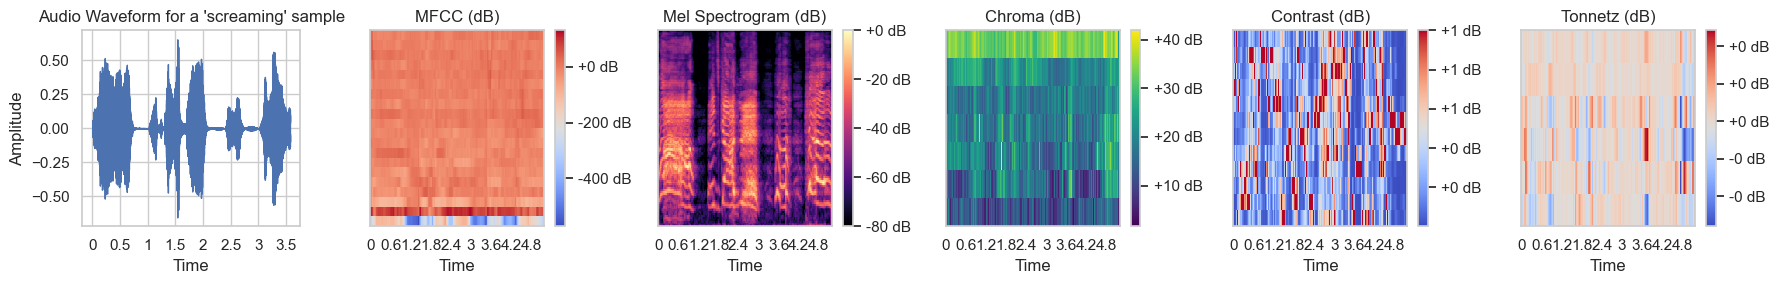

File Path:-  C:/Users/vaibh/Desktop/Desktop/Coding/Machine_Learning/Non-speech-detection/6967442/train/train/PVInYtjLH6k-21_4_0.wav
**********************************************************************************************




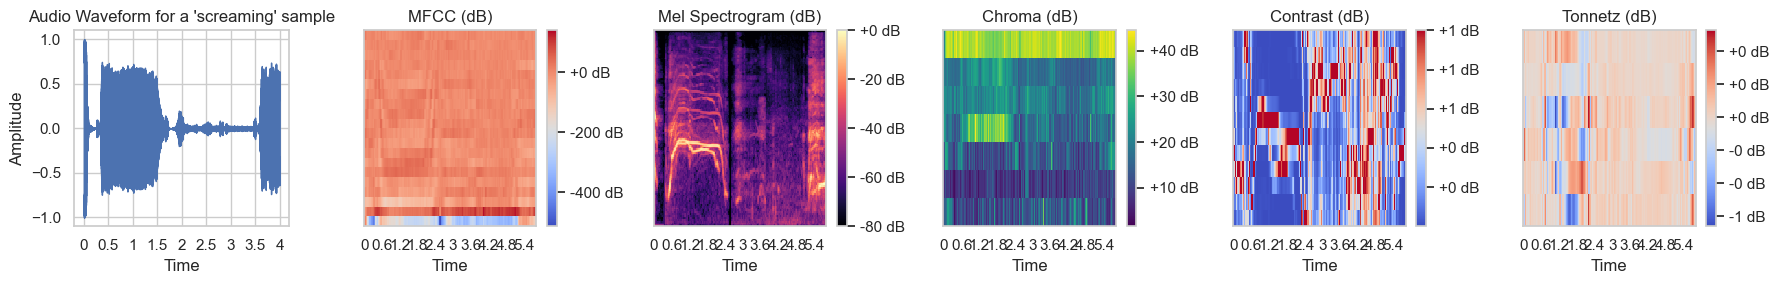

In [36]:
class_samples = metatrain[metatrain['Classname'] == "screaming"].sample(2)
train_path= 'C:/Users/vaibh/Desktop/Desktop/Coding/Machine_Learning/Non-speech-detection/6967442/train/train/'
for index, row in class_samples.iterrows():
  filename = row['Filename']
  file_path = train_path + filename
  print("File Path:- ", file_path)
  print("**********************************************************************************************")
  print("\n")
  # Load audio
  y, sr = librosa.load(file_path, sr=None)

  # Extract features
  mfccs = librosa.feature.mfcc(y=y, sr=sr)
  mel = librosa.feature.melspectrogram(y=y, sr=sr)
  contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
  chroma = librosa.feature.chroma_stft(y=y, sr=sr)
  tonnetz = librosa.feature.tonnetz(y=y, sr=sr)

  if mfccs is not None:

      # Plot audio waveform
      plt.figure(figsize=(18, 3))

      plt.subplot(1, 6, 1)
      librosa.display.waveshow(y, sr=sr)
      plt.title('Audio Waveform for a \'screaming\' sample')
      plt.xlabel('Time')
      plt.ylabel('Amplitude')

      plt.subplot(1, 6, 2)
      librosa.display.specshow(mfccs, x_axis='time')
      plt.colorbar(format='%+2.0f dB')
      plt.title('MFCC (dB)')
      plt.xlabel('Time')
      plt.gca().axes.get_yaxis().set_visible(False)

      plt.subplot(1, 6, 3)
      librosa.display.specshow(librosa.power_to_db(mel, ref=np.max), x_axis='time', y_axis='mel')
      plt.colorbar(format='%+2.0f dB')
      plt.title('Mel Spectrogram (dB)')
      plt.xlabel('Time')
      plt.gca().axes.get_yaxis().set_visible(False)

      plt.subplot(1, 6, 4)
      librosa.display.specshow(contrast, x_axis='time', cmap='viridis')
      plt.colorbar(format='%+2.0f dB')
      plt.title('Chroma (dB)')
      plt.xlabel('Time')
      plt.gca().axes.get_yaxis().set_visible(False)

      plt.subplot(1, 6, 5)
      librosa.display.specshow(chroma, x_axis='time', y_axis='chroma', cmap='coolwarm')
      plt.colorbar(format='%+2.0f dB')
      plt.title('Contrast (dB)')
      plt.xlabel('Time')
      plt.gca().axes.get_yaxis().set_visible(False)

      plt.subplot(1, 6, 6)
      librosa.display.specshow(tonnetz, x_axis='time')
      plt.colorbar(format='%+2.0f dB')
      plt.title('Tonnetz (dB)')
      plt.xlabel('Time')
      plt.gca().axes.get_yaxis().set_visible(False)

      plt.tight_layout()

      plot_filename = "screaming_.png"
      plt.savefig(plot_filename)

      plt.show()
